In [1]:
# --- Core Python ---
import os
import sys
from pathlib import Path
import h5py
import re

# Ensure notebook-local helper modules are importable
_NB_DIR = Path.cwd()
print(f"currently in {_NB_DIR}")
if (_NB_DIR / "resp_helper_functions.py").exists():
    print("helper functions exists in working directory, adding to sys.path")
    sys.path.insert(0, str(_NB_DIR))
else:
    # Fallback when notebook is launched from workspace root
    _NB_DIR = Path("notebooks/thomas_notebooks/resp_classification").resolve()
    if (_NB_DIR / "resp_helper_functions.py").exists():
        sys.path.insert(0, str(_NB_DIR))
    print("Helper functions didn't exist in working directory, resolving and adding to sys.path")

# --- Numerical & data analysis ---
import numpy as np
import pandas as pd

# --- Plotting ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Signal processing ---
from scipy.signal import butter, filtfilt, resample_poly, find_peaks

# --- Statistics ---
from scipy.stats import wilcoxon

# --- Machine learning & metrics ---
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, balanced_accuracy_score
from sklearn.model_selection import StratifiedKFold, StratifiedGroupKFold, LeaveOneGroupOut
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

# --- Specialized neurophysiology tools ---
import neurokit2 as nk

# All the functions used to load, clean, and verify respiration and BORIS data
from resp_helper_functions import *

# --- Pandas display settings ---
pd.set_option("display.max_rows", 50)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 1000)


currently in c:\Users\thoma\Code\ResearchCode\respiratory_pilot
Helper functions didn't exist in working directory, resolving and adding to sys.path
Libraries loaded successfully


In [2]:
np.floor(5*0.1)

np.float64(0.0)

# Load Feature Matrix & Initial Inspection

In [3]:
feature_matrix = pd.read_pickle(r"C:\Users\thoma\Code\ResearchCode\respiratory_pilot\notebooks\thomas_notebooks\resp_classification\data\raw-breathmetrics-features-session-3sec-subjectnames")
feature_matrix.columns

Index(['WindowID', 'Start', 'Stop', 'Duration', 'n_breaths', 'breathing_rate_hz', 'mean_ibi_sec', 'cv_ibi', 'mean_inhale_dur_sec', 'cv_inhale_dur', 'mean_exhale_dur_sec', 'cv_exhale_dur', 'ie_ratio', 'mean_peak_insp_flow', 'mean_peak_exp_flow', 'cv_peak_insp_flow', 'mean_inhale_vol', 'mean_exhale_vol', 'mean_tidal_vol_proxy', 'cv_inhale_vol', 'ventilation_proxy', 'pct_breaths_with_inhale_pause', 'mean_inhale_pause_dur_sec', 'cv_inhale_pause_dur', 'inhale_pause_duty_cycle', 'pct_breaths_with_exhale_pause', 'mean_exhale_pause_dur_sec', 'cv_exhale_pause_dur', 'exhale_pause_duty_cycle', 'inhale_duty_cycle', 'exhale_duty_cycle', 'Trial', 'Subject', 'Recording', 'MouseSubject', 'Condition', 'Rank', 'Type', 'session_duration_sec', 'n_breaths_total', 'WindowSec', 'n_bouts_anogenital_sniffing', 'n_bouts_body_sniffing', 'n_bouts_facial_sniffing', 'total_dur_anogenital_sniffing', 'total_dur_body_sniffing', 'total_dur_facial_sniffing'], dtype='object')

In [4]:
print(feature_matrix["Condition"].value_counts())

Condition
RI1     790
RI2     721
BLRI    696
Name: count, dtype: int64


In [5]:
feature_matrix

,WindowID,Start,Stop,Duration,n_breaths,breathing_rate_hz,mean_ibi_sec,cv_ibi,mean_inhale_dur_sec,cv_inhale_dur,mean_exhale_dur_sec,cv_exhale_dur,ie_ratio,mean_peak_insp_flow,mean_peak_exp_flow,cv_peak_insp_flow,mean_inhale_vol,mean_exhale_vol,mean_tidal_vol_proxy,cv_inhale_vol,ventilation_proxy,pct_breaths_with_inhale_pause,mean_inhale_pause_dur_sec,cv_inhale_pause_dur,inhale_pause_duty_cycle,pct_breaths_with_exhale_pause,mean_exhale_pause_dur_sec,cv_exhale_pause_dur,exhale_pause_duty_cycle,inhale_duty_cycle,exhale_duty_cycle,Trial,Subject,Recording,MouseSubject,Condition,Rank,Type,session_duration_sec,n_breaths_total,WindowSec,n_bouts_anogenital_sniffing,n_bouts_body_sniffing,n_bouts_facial_sniffing,total_dur_anogenital_sniffing,total_dur_body_sniffing,total_dur_facial_sniffing
0,0,0.0,3.0,3.0,23,8.110599,0.123295,0.395847,0.070326,0.686864,0.047283,0.164203,1.487356,1768.609817,-1157.014047,0.277502,78831.242365,36932.542940,115763.785306,0.488165,938913.650405,0.0,0.0000,NaN,0.00000,0.000000,0.000000,NaN,0.000000,0.570387,0.383490,RI1_3_6,3_6,RI1_s3_6_p5_3_nRB3_20250621_125312_merged.h5,3_6,RI1,Dominant,Interaction,603.2700,3902,3.0,9.0,4.0,3.0,16.998,2.068,3.069
1,1,12.0,15.0,3.0,30,9.805579,0.101983,0.286920,0.045417,0.495634,0.051500,0.398650,0.881877,1292.692763,-1233.501638,0.406402,42686.203379,42972.532913,85658.736292,0.583736,839933.508865,0.0,0.0000,NaN,0.00000,0.000000,0.000000,NaN,0.000000,0.445337,0.504987,RI1_3_6,3_6,RI1_s3_6_p5_3_nRB3_20250621_125312_merged.h5,3_6,RI1,Dominant,Interaction,603.2700,3902,3.0,9.0,4.0,3.0,16.998,2.068,3.069
2,2,18.0,21.0,3.0,24,8.148804,0.122717,0.447254,0.063854,0.667111,0.054271,0.429149,1.176583,1444.108153,-1066.021541,0.248866,56169.481664,38887.470925,95056.952588,0.460222,774600.499390,0.0,0.0000,NaN,0.00000,0.000000,0.000000,NaN,0.000000,0.520335,0.442242,RI1_3_6,3_6,RI1_s3_6_p5_3_nRB3_20250621_125312_merged.h5,3_6,RI1,Dominant,Interaction,603.2700,3902,3.0,9.0,4.0,3.0,16.998,2.068,3.069
3,3,21.0,24.0,3.0,30,10.139860,0.098621,0.115992,0.040667,0.142797,0.055583,0.346975,0.731634,1126.167480,-1046.388673,0.279587,32766.613224,39706.729659,72473.342883,0.373237,734869.560705,0.0,0.0000,NaN,0.00000,0.000000,0.000000,NaN,0.000000,0.412354,0.563607,RI1_3_6,3_6,RI1_s3_6_p5_3_nRB3_20250621_125312_merged.h5,3_6,RI1,Dominant,Interaction,603.2700,3902,3.0,9.0,4.0,3.0,16.998,2.068,3.069
4,4,27.0,30.0,3.0,28,9.254499,0.108056,0.270498,0.047054,0.456620,0.055536,0.347103,0.847267,1162.672678,-957.341416,0.270349,37575.630047,36570.975907,74146.605953,0.470774,686189.669489,0.0,0.0000,NaN,0.00000,0.000000,0.000000,NaN,0.000000,0.435457,0.513955,RI1_3_6,3_6,RI1_s3_6_p5_3_nRB3_20250621_125312_merged.h5,3_6,RI1,Dominant,Interaction,603.2700,3902,3.0,9.0,4.0,3.0,16.998,2.068,3.069
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2202,95,573.0,576.0,3.0,17,5.465414,0.182969,0.665479,0.079706,0.702906,0.082794,0.501096,0.962700,1590.195779,-1180.402324,0.331834,62130.668583,57021.244798,119151.913381,0.324151,651214.556482,0.0,0.0000,NaN,0.00000,0.117647,0.261250,0.387560,0.167981,0.435626,0.452504,BLRI_4_8,4_8,BLRI_s4_8_p5_1_nRB3_20250621_163506_merged.h5,4_8,BLRI,Dominant,Baseline,605.0125,4351,3.0,NaN,NaN,NaN,NaN,NaN,NaN
2203,96,579.0,582.0,3.0,20,6.991720,0.143026,0.378670,0.057500,0.304348,0.072625,0.423768,0.791738,1471.607876,-1193.341595,0.301127,55009.831975,54594.686425,109604.518400,0.413162,766324.139687,0.1,0.0725,0.034483,0.05069,0.150000,0.129167,0.949023,0.135465,0.402024,0.507774,BLRI_4_8,4_8,BLRI_s4_8_p5_1_nRB3_20250621_163506_merged.h5,4_8,BLRI,Dominant,Baseline,605.0125,4351,3.0,NaN,NaN,NaN,NaN,NaN,NaN
2204,97,588.0,591.0,3.0,28,9.326425,0.107222,0.116897,0.044821,0.123763,0.057143,0.235228,0.784375,1600.322165,-1370.511427,0.309837,50512.089785,51802.887739,102314.977525,0.374042,954232.951007,0.0,0.0000,NaN,0.00000,0.000000,0.0

In [6]:
feature_matrix.columns

Index(['WindowID', 'Start', 'Stop', 'Duration', 'n_breaths', 'breathing_rate_hz', 'mean_ibi_sec', 'cv_ibi', 'mean_inhale_dur_sec', 'cv_inhale_dur', 'mean_exhale_dur_sec', 'cv_exhale_dur', 'ie_ratio', 'mean_peak_insp_flow', 'mean_peak_exp_flow', 'cv_peak_insp_flow', 'mean_inhale_vol', 'mean_exhale_vol', 'mean_tidal_vol_proxy', 'cv_inhale_vol', 'ventilation_proxy', 'pct_breaths_with_inhale_pause', 'mean_inhale_pause_dur_sec', 'cv_inhale_pause_dur', 'inhale_pause_duty_cycle', 'pct_breaths_with_exhale_pause', 'mean_exhale_pause_dur_sec', 'cv_exhale_pause_dur', 'exhale_pause_duty_cycle', 'inhale_duty_cycle', 'exhale_duty_cycle', 'Trial', 'Subject', 'Recording', 'MouseSubject', 'Condition', 'Rank', 'Type', 'session_duration_sec', 'n_breaths_total', 'WindowSec', 'n_bouts_anogenital_sniffing', 'n_bouts_body_sniffing', 'n_bouts_facial_sniffing', 'total_dur_anogenital_sniffing', 'total_dur_body_sniffing', 'total_dur_facial_sniffing'], dtype='object')

# Define Target Classes & Extract Feature Matrix

## Take Out Non Resp Features

In [7]:
# Keep only target classes of interest
TARGET_COL = "Condition"
TARGET_CLASSES = ["RI1", "RI2"]

df = feature_matrix.copy()
df = df[df[TARGET_COL].isin(TARGET_CLASSES)].reset_index(drop=True)

# -------------------------------------------------------------------
# TrueMouseID: one biological mouse across RI1 and RI2 (correct LOSO unit).
# Trial is often RI1_1_1 / RI2_1_1; older pickles may lack MouseSubject but still have Trial.
# MouseSubject from extraction can be the filename pair (e.g. 1_1) without an RI prefix.
# -------------------------------------------------------------------
def _strip_ri12_prefix(s: pd.Series) -> pd.Series:
    return s.astype(str).str.replace(r"^RI[12]_", "", regex=True)


true_id = None
if "Trial" in df.columns:
    t = df["Trial"].astype(str)
    if t.str.match(r"^RI[12]_", na=False).any():
        true_id = _strip_ri12_prefix(t)
if true_id is None and "MouseSubject" in df.columns:
    m = df["MouseSubject"].astype(str)
    true_id = (
        _strip_ri12_prefix(m)
        if m.str.match(r"^RI[12]_", na=False).any()
        else m
    )
if true_id is None and "Subject" in df.columns:
    true_id = df["Subject"].astype(str)

if true_id is None:
    raise ValueError(
        "Could not build TrueMouseID: need 'Trial' (RI1_/RI2_…), "
        "'MouseSubject', or 'Subject' on the feature matrix."
    )

df["TrueMouseID"] = true_id

group_summary = (
    df.groupby("TrueMouseID", observed=True)[TARGET_COL]
    .value_counts()
    .unstack(fill_value=0)
    .sort_index()
)
print("=" * 80)
print("Per-true-mouse class balance (windows)")
print("=" * 80)
display(group_summary)
print("n unique TrueMouseID:", df["TrueMouseID"].nunique())

# Keep only true mice that contain both RI1 and RI2
n_cls_per_mouse = df.groupby("TrueMouseID", observed=True)[TARGET_COL].nunique()
valid_mice = n_cls_per_mouse[n_cls_per_mouse > 1].index
excluded_mice = sorted(set(df["TrueMouseID"].unique()) - set(valid_mice))

if excluded_mice:
    print(
        f"Excluding {len(excluded_mice)} true mouse ID(s) with only one target class: "
        f"{excluded_mice}"
    )

df = df[df["TrueMouseID"].isin(valid_mice)].reset_index(drop=True)

if len(df) == 0:
    raise ValueError("No rows left after excluding single-class true mice.")

# Explicit metadata + non-feature columns to exclude
EXCLUDE_FROM_FEATURES = {
    TARGET_COL,
    "Behavior",
    "Start",
    "Stop",
    "Duration",
    "Trial",
    "Subject",
    "Recording",
    "MouseSubject",
    "TrueMouseID",
    "Rank",
    "Type",
    "Label",
    "WindowID",
    "WindowSec",
    "session_duration_sec",
    "n_breaths_total",
}

if "METADATA_COLS" in globals() and isinstance(METADATA_COLS, (list, tuple, set)):
    EXCLUDE_FROM_FEATURES.update(METADATA_COLS)

# Keep only numeric respiration features (drop any BORIS/behavior summary columns)
BEHAVIOR_COL_PREFIXES = (
    "n_bouts_",
    "total_dur_",
)

candidate_feature_cols = [
    c
    for c in df.columns
    if (
        c not in EXCLUDE_FROM_FEATURES
        and pd.api.types.is_numeric_dtype(df[c])
        and not str(c).startswith(BEHAVIOR_COL_PREFIXES)
    )
]

X_all = df[candidate_feature_cols].copy()
y = df[TARGET_COL].copy()

groups = df["TrueMouseID"].copy()
GROUP_KEY_FOR_CV = "TrueMouseID"

Per-true-mouse class balance (windows)


Condition,RI1,RI2
TrueMouseID,,
1_1,100,100
1_2,96,91
2_3,98,95
2_4,100,82
3_5,100,71
3_6,100,83
4_7,100,100
4_8,96,99


n unique TrueMouseID: 8


In [8]:
df[candidate_feature_cols].columns


Index(['n_breaths', 'breathing_rate_hz', 'mean_ibi_sec', 'cv_ibi', 'mean_inhale_dur_sec', 'cv_inhale_dur', 'mean_exhale_dur_sec', 'cv_exhale_dur', 'ie_ratio', 'mean_peak_insp_flow', 'mean_peak_exp_flow', 'cv_peak_insp_flow', 'mean_inhale_vol', 'mean_exhale_vol', 'mean_tidal_vol_proxy', 'cv_inhale_vol', 'ventilation_proxy', 'pct_breaths_with_inhale_pause', 'mean_inhale_pause_dur_sec', 'cv_inhale_pause_dur', 'inhale_pause_duty_cycle', 'pct_breaths_with_exhale_pause', 'mean_exhale_pause_dur_sec', 'cv_exhale_pause_dur', 'exhale_pause_duty_cycle', 'inhale_duty_cycle', 'exhale_duty_cycle'], dtype='object')

# Model Setup: Grouped Cross-Validation, Feature Selection, and Baseline Model Definitions

In [9]:
# Inner model-selection CV: stratified by class, grouped so the same TrueMouseID
# never appears in both train and validation folds.
if groups is not None and groups.nunique() >= 3:
    n_splits = min(5, groups.nunique())
    cv = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=42)
    gname = GROUP_KEY_FOR_CV or "group"
    cv_mode = (
        f"StratifiedGroupKFold(n_splits={n_splits}, shuffle=True, random_state=42) "
        f"[group={gname}]"
    )
else:
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_mode = "StratifiedKFold(n_splits=5, shuffle=True, random_state=42)"

# Drop feature columns with too many missing values
MAX_MISSING_FRAC = 0.40
missing_frac = X_all.isna().mean(axis=0)
kept_feature_cols = missing_frac[missing_frac <= MAX_MISSING_FRAC].index.tolist()
dropped_feature_cols = missing_frac[missing_frac > MAX_MISSING_FRAC].sort_values(ascending=False)

X = X_all[kept_feature_cols].copy()

# Preprocessing pipeline with imputation + scaling (for linear models and SVM)
preprocess_numeric = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

# Preprocessing pipeline with imputation only (for tree-based models)
preprocess_impute_only = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

# End-to-end model pipelines (safe against leakage when used in grouped CV)
logreg_clf = Pipeline([
    ("preprocess", preprocess_numeric),
    ("model", LogisticRegression(max_iter=5000, class_weight="balanced")),
])

svm_clf = Pipeline([
    ("preprocess", preprocess_numeric),
    ("model", SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=42)),
])

svm_linear_clf = Pipeline([
    ("preprocess", preprocess_numeric),
    ("model", LinearSVC(
        class_weight="balanced",
        max_iter=5000,
        random_state=42
    )),
])

rf_clf = Pipeline([
    ("preprocess", preprocess_impute_only),
    ("model", RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        max_depth=None,
        random_state=42,
        n_jobs=-1,
    )),
])

print(f"Rows retained after target filter: {len(df)}")
print(f"Target class counts:\n{y.value_counts(dropna=False)}\n")
print(f"Candidate numeric resp features: {len(candidate_feature_cols)}")
print(f"Features kept (<= {MAX_MISSING_FRAC:.0%} missing): {X.shape[1]}")
print(f"Features dropped (> {MAX_MISSING_FRAC:.0%} missing): {len(dropped_feature_cols)}")
if len(dropped_feature_cols):
    print("Dropped columns and missing fraction:")
    display(dropped_feature_cols.to_frame(name="missing_fraction"))

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"groups available: {groups is not None}")
print(f"CV strategy (for GridSearch / learning curves): {cv_mode}")

# --- Shared leave-one-mouse-out evaluation (following cells call this) ---
from sklearn.base import clone
from sklearn.metrics import f1_score, classification_report, confusion_matrix, balanced_accuracy_score
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.utils.class_weight import compute_sample_weight

classes = np.sort(y.unique())


def _recording_level_from_windows(y_true_arr, y_pred_arr, recordings, label_classes):
    'One valence label per recording via majority vote over its windows.'
    d = pd.DataFrame(
        {"Recording": recordings, "y_true": y_true_arr, "y_pred": y_pred_arr}
    )

    def _mode(s):
        m = s.mode()
        return m.iloc[0] if len(m) else np.nan

    yt = d.groupby("Recording", observed=True)["y_true"].agg(_mode)
    yp = d.groupby("Recording", observed=True)["y_pred"].agg(_mode)
    common = yt.index.intersection(yp.index)
    yt = yt.loc[common]
    yp = yp.loc[common]
    if len(common) == 0:
        return np.nan, np.nan
    ba = balanced_accuracy_score(yt, yp)
    f1 = f1_score(yt, yp, labels=label_classes, average="macro", zero_division=0)
    return ba, f1


def evaluate_mouse_loso(base_model, model_name, shuffle_labels=False):
    # Leave-one-mouse-out on windows; recording-level majority vote as secondary metric.
    if groups is None or groups.nunique() < 2:
        raise ValueError("Need at least 2 mice (group IDs) for leave-one-mouse-out.")

    y_eval = y.copy()
    if shuffle_labels:
        rng = np.random.RandomState(42)
        y_eval = pd.Series(rng.permutation(y_eval.values), index=y_eval.index)

    loo = LeaveOneGroupOut()
    bal_m, f1_m = [], []
    bal_r, f1_r = [], []
    y_true_all, y_pred_all = [], []

    for fold_idx, (train_idx, test_idx) in enumerate(
        loo.split(X, y_eval, groups=groups), start=1
    ):
        held_mouse = groups.iloc[test_idx].iloc[0]
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y_eval.iloc[train_idx], y_eval.iloc[test_idx]

        fold_sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)
        model = clone(base_model)
        model.fit(X_train, y_train, model__sample_weight=fold_sample_weights)
        y_pred = model.predict(X_test)

        ba = balanced_accuracy_score(y_test, y_pred)
        mf1 = f1_score(
            y_test, y_pred, labels=classes, average="macro", zero_division=0
        )

        # Flip-check for possible RI1/RI2 inversion in a held-out mouse.
        y_pred_flipped = np.where(np.asarray(y_pred) == "RI1", "RI2", "RI1")
        ba_flip = balanced_accuracy_score(y_test, y_pred_flipped)
        mf1_flip = f1_score(
            y_test, y_pred_flipped, labels=classes, average="macro", zero_division=0
        )

        bal_m.append(ba)
        f1_m.append(mf1)

        if "Recording" in df.columns:
            rec_col = df.iloc[test_idx]["Recording"].values
            bar, f1rec = _recording_level_from_windows(
                y_test.values, y_pred, rec_col, classes
            )
        else:
            bar, f1rec = np.nan, np.nan
        bal_r.append(bar)
        f1_r.append(f1rec)

        y_true_all.extend(y_test)
        y_pred_all.extend(y_pred)

        print(
            f"[{model_name}] held-out mouse={held_mouse} (fold {fold_idx}): "
            f"window bal_acc={ba:.3f}, macro_f1={mf1:.3f} | "
            f"recording bal_acc={bar:.3f}, macro_f1={f1rec:.3f}"
        )
        print(
            f"    flip-check: original bal_acc={ba:.3f}, macro_f1={mf1:.3f} | "
            f"flipped bal_acc={ba_flip:.3f}, macro_f1={mf1_flip:.3f}"
        )

    bal_m = np.asarray(bal_m, dtype=float)
    f1_m = np.asarray(f1_m, dtype=float)
    bal_r = np.asarray(bal_r, dtype=float)
    f1_r = np.asarray(f1_r, dtype=float)

    tag = "  [label shuffle]" if shuffle_labels else ""
    print(f"\n[{model_name}] Mouse-level (held-out windows) - mean +/- std over mice{tag}:")
    print(f"  balanced accuracy: {bal_m.mean():.3f} +/- {bal_m.std():.3f}  (n={len(bal_m)} mice)")
    print(f"  macro F1:          {f1_m.mean():.3f} +/- {f1_m.std():.3f}")
    print(f"\n[{model_name}] Recording-level (majority vote over windows){tag}:")
    print(f"  balanced accuracy: {np.nanmean(bal_r):.3f} +/- {np.nanstd(bal_r):.3f}")
    print(f"  macro F1:          {np.nanmean(f1_r):.3f} +/- {np.nanstd(f1_r):.3f}")

    if not shuffle_labels:
        print(f"\n[{model_name}] Pooled window-level OOF report:")
        print(classification_report(y_true_all, y_pred_all, labels=classes, zero_division=0))
        cm = confusion_matrix(y_true_all, y_pred_all, labels=classes)
        cm_df = pd.DataFrame(
            cm,
            index=[f"true_{c}" for c in classes],
            columns=[f"pred_{c}" for c in classes],
        )
        display(cm_df)


Rows retained after target filter: 1511
Target class counts:
Condition
RI1    790
RI2    721
Name: count, dtype: int64

Candidate numeric resp features: 27
Features kept (<= 40% missing): 25
Features dropped (> 40% missing): 2
Dropped columns and missing fraction:


,missing_fraction
cv_inhale_pause_dur,0.970880
cv_exhale_pause_dur,0.769689


X shape: (1511, 25)
y shape: (1511,)
groups available: True
CV strategy (for GridSearch / learning curves): StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42) [group=TrueMouseID]


# Primary Leave-One-Mouse-Out Evaluation and Leakage Check

In [10]:
if groups is None:
    raise ValueError(
        "No grouping column for LOSO. Expected TrueMouseID on df (see target-class cell)."
    )

print("=" * 80)
print("Per-TrueMouseID class balance (windows) - inspect before LOSO")
print("=" * 80)
_mouse_bal = (
    df.assign(_mouse_group=groups.values)
    .groupby("_mouse_group", observed=True)[TARGET_COL]
    .value_counts()
    .unstack(fill_value=0)
)
display(_mouse_bal.sort_index())
print(f"\nUnique TrueMouseID (grouping variable): {groups.nunique()}")

print("\n" + "=" * 80)
print("Primary evaluation: Leave-One-Mouse-Out (LOMO / LOSO)")
print("Question: Do respiration features generalize valence to a new mouse?")
print("=" * 80 + "\n")

evaluate_mouse_loso(logreg_clf, "LogisticRegression", shuffle_labels=False)
print("\n" + "=" * 80 + "\n")
evaluate_mouse_loso(svm_clf, "SVM", shuffle_labels=False)
print("\n" + "=" * 80 + "\n")

evaluate_mouse_loso(svm_linear_clf, "LinearSVM", shuffle_labels=False)
print("\n" + "=" * 80 + "\n")

evaluate_mouse_loso(rf_clf, "RandomForest", shuffle_labels=False)

print("\n" + "=" * 80)
print("Label-shuffle sanity check (LogisticRegression). High score => possible leakage.")
print("=" * 80 + "\n")
evaluate_mouse_loso(logreg_clf, "LogisticRegression_shuffled_y", shuffle_labels=True)


Per-TrueMouseID class balance (windows) - inspect before LOSO


Condition,RI1,RI2
_mouse_group,,
1_1,100,100
1_2,96,91
2_3,98,95
2_4,100,82
3_5,100,71
3_6,100,83
4_7,100,100
4_8,96,99



Unique TrueMouseID (grouping variable): 8

Primary evaluation: Leave-One-Mouse-Out (LOMO / LOSO)
Question: Do respiration features generalize valence to a new mouse?

[LogisticRegression] held-out mouse=1_1 (fold 1): window bal_acc=0.810, macro_f1=0.810 | recording bal_acc=1.000, macro_f1=1.000
    flip-check: original bal_acc=0.810, macro_f1=0.810 | flipped bal_acc=0.190, macro_f1=0.190
[LogisticRegression] held-out mouse=1_2 (fold 2): window bal_acc=0.709, macro_f1=0.708 | recording bal_acc=1.000, macro_f1=1.000
    flip-check: original bal_acc=0.709, macro_f1=0.708 | flipped bal_acc=0.291, macro_f1=0.285
[LogisticRegression] held-out mouse=2_3 (fold 3): window bal_acc=0.745, macro_f1=0.743 | recording bal_acc=1.000, macro_f1=1.000
    flip-check: original bal_acc=0.745, macro_f1=0.743 | flipped bal_acc=0.255, macro_f1=0.247
[LogisticRegression] held-out mouse=2_4 (fold 4): window bal_acc=0.874, macro_f1=0.880 | recording bal_acc=1.000, macro_f1=1.000
    flip-check: original bal_ac

,pred_RI1,pred_RI2
true_RI1,675,115
true_RI2,189,532




[SVM] held-out mouse=1_1 (fold 1): window bal_acc=0.845, macro_f1=0.845 | recording bal_acc=1.000, macro_f1=1.000
    flip-check: original bal_acc=0.845, macro_f1=0.845 | flipped bal_acc=0.155, macro_f1=0.155
[SVM] held-out mouse=1_2 (fold 2): window bal_acc=0.697, macro_f1=0.694 | recording bal_acc=1.000, macro_f1=1.000
    flip-check: original bal_acc=0.697, macro_f1=0.694 | flipped bal_acc=0.303, macro_f1=0.290
[SVM] held-out mouse=2_3 (fold 3): window bal_acc=0.750, macro_f1=0.748 | recording bal_acc=1.000, macro_f1=1.000
    flip-check: original bal_acc=0.750, macro_f1=0.748 | flipped bal_acc=0.250, macro_f1=0.242
[SVM] held-out mouse=2_4 (fold 4): window bal_acc=0.873, macro_f1=0.880 | recording bal_acc=1.000, macro_f1=1.000
    flip-check: original bal_acc=0.873, macro_f1=0.880 | flipped bal_acc=0.127, macro_f1=0.106
[SVM] held-out mouse=3_5 (fold 5): window bal_acc=0.824, macro_f1=0.825 | recording bal_acc=1.000, macro_f1=1.000
    flip-check: original bal_acc=0.824, macro_f1

...

,pred_RI1,pred_RI2
true_RI1,678,112
true_RI2,202,519




[RandomForest] held-out mouse=1_1 (fold 1): window bal_acc=0.850, macro_f1=0.850 | recording bal_acc=1.000, macro_f1=1.000
    flip-check: original bal_acc=0.850, macro_f1=0.850 | flipped bal_acc=0.150, macro_f1=0.149
[RandomForest] held-out mouse=1_2 (fold 2): window bal_acc=0.708, macro_f1=0.704 | recording bal_acc=1.000, macro_f1=1.000
    flip-check: original bal_acc=0.708, macro_f1=0.704 | flipped bal_acc=0.292, macro_f1=0.277
[RandomForest] held-out mouse=2_3 (fold 3): window bal_acc=0.744, macro_f1=0.740 | recording bal_acc=1.000, macro_f1=1.000
    flip-check: original bal_acc=0.744, macro_f1=0.740 | flipped bal_acc=0.256, macro_f1=0.239
[RandomForest] held-out mouse=2_4 (fold 4): window bal_acc=0.878, macro_f1=0.885 | recording bal_acc=1.000, macro_f1=1.000
    flip-check: original bal_acc=0.878, macro_f1=0.885 | flipped bal_acc=0.122, macro_f1=0.099
[RandomForest] held-out mouse=3_5 (fold 5): window bal_acc=0.805, macro_f1=0.807 | recording bal_acc=1.000, macro_f1=1.000
   

,pred_RI1,pred_RI2
true_RI1,708,82
true_RI2,203,518



Label-shuffle sanity check (LogisticRegression). High score => possible leakage.

[LogisticRegression_shuffled_y] held-out mouse=1_1 (fold 1): window bal_acc=0.491, macro_f1=0.488 | recording bal_acc=0.500, macro_f1=0.333
    flip-check: original bal_acc=0.491, macro_f1=0.488 | flipped bal_acc=0.509, macro_f1=0.507
[LogisticRegression_shuffled_y] held-out mouse=1_2 (fold 2): window bal_acc=0.495, macro_f1=0.480 | recording bal_acc=0.500, macro_f1=0.333
    flip-check: original bal_acc=0.495, macro_f1=0.480 | flipped bal_acc=0.505, macro_f1=0.494
[LogisticRegression_shuffled_y] held-out mouse=2_3 (fold 3): window bal_acc=0.529, macro_f1=0.529 | recording bal_acc=0.500, macro_f1=0.333
    flip-check: original bal_acc=0.529, macro_f1=0.529 | flipped bal_acc=0.471, macro_f1=0.466
[LogisticRegression_shuffled_y] held-out mouse=2_4 (fold 4): window bal_acc=0.551, macro_f1=0.539 | recording bal_acc=0.500, macro_f1=0.333
    flip-check: original bal_acc=0.551, macro_f1=0.539 | flipped bal_acc

c:\Users\thoma\miniconda3\envs\biopipeline-env\Lib\site-packages\sklearn\metrics\_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\thoma\miniconda3\envs\biopipeline-env\Lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\Users\thoma\miniconda3\envs\biopipeline-env\Lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


# Regularized Model Evaluation and Learning Curve Analysis

Learning-curve CV: StratifiedGroupKFold(n_splits=5, shuffle=True) [mouse-level groups]
Regularized models - same LOMO protocol as previous cell


  LogisticRegression_L2

[LogisticRegression_L2] held-out mouse=1_1 (fold 1): window bal_acc=0.830, macro_f1=0.830 | recording bal_acc=1.000, macro_f1=1.000
    flip-check: original bal_acc=0.830, macro_f1=0.830 | flipped bal_acc=0.170, macro_f1=0.170
[LogisticRegression_L2] held-out mouse=1_2 (fold 2): window bal_acc=0.676, macro_f1=0.674 | recording bal_acc=1.000, macro_f1=1.000
    flip-check: original bal_acc=0.676, macro_f1=0.674 | flipped bal_acc=0.324, macro_f1=0.315
[LogisticRegression_L2] held-out mouse=2_3 (fold 3): window bal_acc=0.734, macro_f1=0.731 | recording bal_acc=1.000, macro_f1=1.000
    flip-check: original bal_acc=0.734, macro_f1=0.731 | flipped bal_acc=0.266, macro_f1=0.254
[LogisticRegression_L2] held-out mouse=2_4 (fold 4): window bal_acc=0.873, macro_f1=0.880 | recording bal_acc=1.000, macro_f1=1.000
    flip-check: 

,pred_RI1,pred_RI2
true_RI1,680,110
true_RI2,200,521


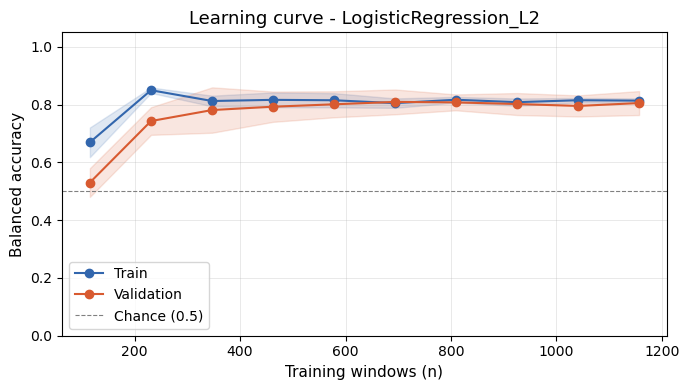

[LogisticRegression_L2] Validation curve verdict: flattened - data volume looks sufficient for this model


  SVM_RBF_regularized

[SVM_RBF_regularized] held-out mouse=1_1 (fold 1): window bal_acc=0.835, macro_f1=0.835 | recording bal_acc=1.000, macro_f1=1.000
    flip-check: original bal_acc=0.835, macro_f1=0.835 | flipped bal_acc=0.165, macro_f1=0.163
[SVM_RBF_regularized] held-out mouse=1_2 (fold 2): window bal_acc=0.701, macro_f1=0.695 | recording bal_acc=1.000, macro_f1=1.000
    flip-check: original bal_acc=0.701, macro_f1=0.695 | flipped bal_acc=0.299, macro_f1=0.274
[SVM_RBF_regularized] held-out mouse=2_3 (fold 3): window bal_acc=0.723, macro_f1=0.720 | recording bal_acc=1.000, macro_f1=1.000
    flip-check: original bal_acc=0.723, macro_f1=0.720 | flipped bal_acc=0.277, macro_f1=0.264
[SVM_RBF_regularized] held-out mouse=2_4 (fold 4): window bal_acc=0.805, macro_f1=0.810 | recording bal_acc=1.000, macro_f1=1.000
    flip-check: original bal_acc=0.805, macro_f1=0.810 | flipped

,pred_RI1,pred_RI2
true_RI1,714,76
true_RI2,249,472


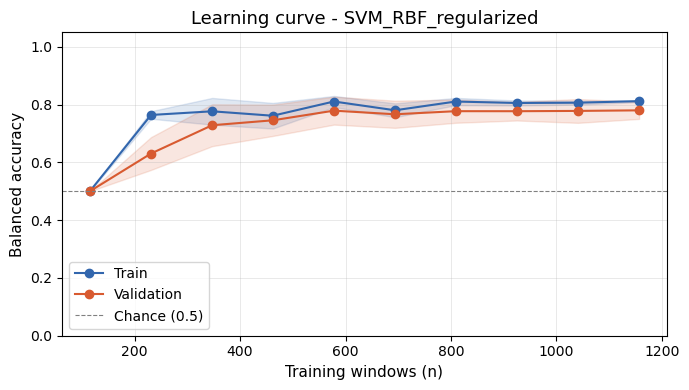

[SVM_RBF_regularized] Validation curve verdict: flattened - data volume looks sufficient for this model


  LinearSVM_regularized

[LinearSVM_regularized] held-out mouse=1_1 (fold 1): window bal_acc=0.810, macro_f1=0.810 | recording bal_acc=1.000, macro_f1=1.000
    flip-check: original bal_acc=0.810, macro_f1=0.810 | flipped bal_acc=0.190, macro_f1=0.190
[LinearSVM_regularized] held-out mouse=1_2 (fold 2): window bal_acc=0.698, macro_f1=0.697 | recording bal_acc=1.000, macro_f1=1.000
    flip-check: original bal_acc=0.698, macro_f1=0.697 | flipped bal_acc=0.302, macro_f1=0.294
[LinearSVM_regularized] held-out mouse=2_3 (fold 3): window bal_acc=0.744, macro_f1=0.742 | recording bal_acc=1.000, macro_f1=1.000
    flip-check: original bal_acc=0.744, macro_f1=0.742 | flipped bal_acc=0.256, macro_f1=0.245
[LinearSVM_regularized] held-out mouse=2_4 (fold 4): window bal_acc=0.862, macro_f1=0.868 | recording bal_acc=1.000, macro_f1=1.000
    flip-check: original bal_acc=0.862, macro_f1=0.868 |

,pred_RI1,pred_RI2
true_RI1,679,111
true_RI2,201,520


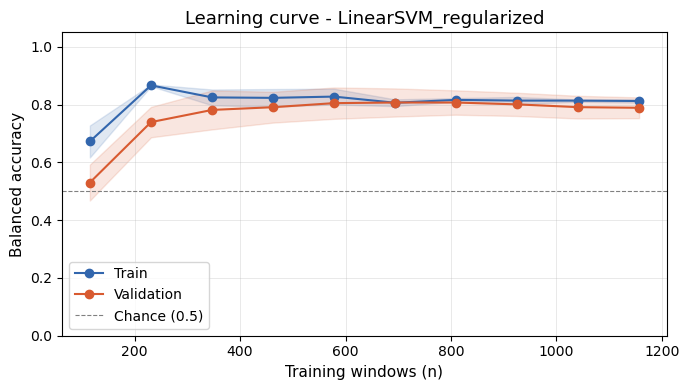

[LinearSVM_regularized] Validation curve verdict: flattened - data volume looks sufficient for this model


  RandomForest_regularized

[RandomForest_regularized] held-out mouse=1_1 (fold 1): window bal_acc=0.850, macro_f1=0.849 | recording bal_acc=1.000, macro_f1=1.000
    flip-check: original bal_acc=0.850, macro_f1=0.849 | flipped bal_acc=0.150, macro_f1=0.147
[RandomForest_regularized] held-out mouse=1_2 (fold 2): window bal_acc=0.691, macro_f1=0.683 | recording bal_acc=1.000, macro_f1=1.000
    flip-check: original bal_acc=0.691, macro_f1=0.683 | flipped bal_acc=0.309, macro_f1=0.285
[RandomForest_regularized] held-out mouse=2_3 (fold 3): window bal_acc=0.744, macro_f1=0.738 | recording bal_acc=1.000, macro_f1=1.000
    flip-check: original bal_acc=0.744, macro_f1=0.738 | flipped bal_acc=0.256, macro_f1=0.234
[RandomForest_regularized] held-out mouse=2_4 (fold 4): window bal_acc=0.848, macro_f1=0.855 | recording bal_acc=1.000, macro_f1=1.000
    flip-check: original bal_acc=0.848,

,pred_RI1,pred_RI2
true_RI1,719,71
true_RI2,228,493


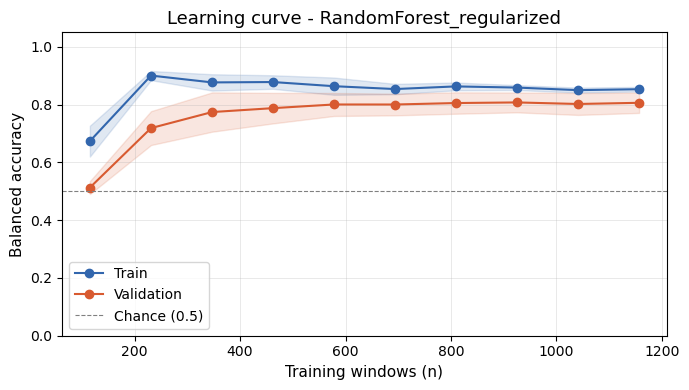

[RandomForest_regularized] Validation curve verdict: flattened - data volume looks sufficient for this model



In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold, learning_curve

# Explicitly regularized models (separate pipelines from the default cell above)

preprocess_numeric = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

preprocess_impute_only = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

logreg_clf = Pipeline([
    ("preprocess", preprocess_numeric),
    ("model", LogisticRegression(
        penalty="l2",
        C=0.1,
        class_weight=None,
        solver="liblinear",
        max_iter=2000,
        random_state=42
    ))
])

svm_clf = Pipeline([
    ("preprocess", preprocess_numeric),
    ("model", SVC(
        kernel="rbf",
        C=0.1,
        gamma="scale",
        class_weight=None,
        random_state=42
    ))
])

svm_linear_clf = Pipeline([
    ("preprocess", preprocess_numeric),
    ("model", LinearSVC(
        C=0.1,
        class_weight=None,
        max_iter=5000,
        random_state=42
    ))
])

rf_clf = Pipeline([
    ("preprocess", preprocess_impute_only),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=5,
        max_features="sqrt",
        bootstrap=True,
        class_weight=None,
        random_state=42,
        n_jobs=-1
    ))
])

# Learning curves use grouped CV by mouse (same as GridSearch inner CV)
if groups is not None and pd.Series(groups).nunique() >= 3:
    n_splits_eval = min(5, pd.Series(groups).nunique())
    cv_lc = StratifiedGroupKFold(n_splits=n_splits_eval, shuffle=True, random_state=42)
    cv_lc_mode = f"StratifiedGroupKFold(n_splits={n_splits_eval}, shuffle=True) [mouse-level groups]"
else:
    n_splits_eval = 5
    cv_lc = StratifiedKFold(n_splits=n_splits_eval, shuffle=True, random_state=42)
    cv_lc_mode = "StratifiedKFold(n_splits=5, shuffle=True, random_state=42)"

print(f"Learning-curve CV: {cv_lc_mode}")
print("Regularized models - same LOMO protocol as previous cell\n")


def plot_learning_curve(base_model, model_name, train_sizes=np.linspace(0.1, 1.0, 10)):
    lc_kwargs = dict(
        estimator=base_model,
        X=X,
        y=y,
        cv=cv_lc,
        scoring="balanced_accuracy",
        train_sizes=train_sizes,
        n_jobs=-1,
        return_times=False,
    )
    if groups is not None and pd.Series(groups).nunique() >= 3:
        lc_kwargs["groups"] = groups

    train_sizes_abs, train_scores, val_scores = learning_curve(**lc_kwargs)

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(train_sizes_abs, train_mean, "o-", color="#3266ad", label="Train")
    ax.fill_between(train_sizes_abs, train_mean - train_std, train_mean + train_std, alpha=0.15, color="#3266ad")
    ax.plot(train_sizes_abs, val_mean, "o-", color="#d85a30", label="Validation")
    ax.fill_between(train_sizes_abs, val_mean - val_std, val_mean + val_std, alpha=0.15, color="#d85a30")

    ax.set_title(f"Learning curve - {model_name}", fontsize=13)
    ax.set_xlabel("Training windows (n)", fontsize=11)
    ax.set_ylabel("Balanced accuracy", fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, label="Chance (0.5)")
    ax.legend(fontsize=10)
    ax.grid(True, linewidth=0.4, alpha=0.5)
    plt.tight_layout()
    plt.show()

    val_slope = val_mean[-1] - val_mean[-3]
    if val_slope > 0.02:
        verdict = "still rising - consider collecting more windows"
    elif val_mean[-1] < 0.55:
        verdict = "flat but low - model may need different features, not more data"
    else:
        verdict = "flattened - data volume looks sufficient for this model"
    print(f"[{model_name}] Validation curve verdict: {verdict}\n")


for model, name in [
    (logreg_clf, "LogisticRegression_L2"),
    (svm_clf, "SVM_RBF_regularized"),
    (svm_linear_clf, "LinearSVM_regularized"),
    (rf_clf, "RandomForest_regularized")
]:

    print(f"\n{'='*80}")
    print(f"  {name}")
    print(f"{'='*80}\n")

    evaluate_mouse_loso(model, name, shuffle_labels=False)
    print()
    plot_learning_curve(model, name)

In [12]:
# NaN audit + drop columns/rows with excessive missingness
COL_NAN_THRESHOLD = 0.40
ROW_NAN_THRESHOLD = 0.40

nan_by_col = feature_matrix.isna().sum().sort_values(ascending=False)
nan_by_row = feature_matrix.isna().sum(axis=1)

total_nans = int(nan_by_col.sum())
col_nan_frac = feature_matrix.isna().mean(axis=0)
row_nan_frac = feature_matrix.isna().mean(axis=1)

cols_to_drop = col_nan_frac[col_nan_frac > COL_NAN_THRESHOLD].index.tolist()
rows_to_drop = row_nan_frac[row_nan_frac > ROW_NAN_THRESHOLD].index.tolist()

feature_matrix_clean = (
    feature_matrix
    .drop(columns=cols_to_drop)
    .drop(index=rows_to_drop)
    .reset_index(drop=True)
)

print(f"Total NaNs in feature_matrix: {total_nans}")
print(f"Columns with >=1 NaN: {(nan_by_col > 0).sum()} / {feature_matrix.shape[1]}")
print(f"Rows with >=1 NaN: {(nan_by_row > 0).sum()} / {feature_matrix.shape[0]}\n")

print(f"Columns dropped (> {COL_NAN_THRESHOLD:.0%} NaN): {len(cols_to_drop)}")
if cols_to_drop:
    display(col_nan_frac.loc[cols_to_drop].sort_values(ascending=False).to_frame("nan_fraction"))

print(f"Rows dropped (> {ROW_NAN_THRESHOLD:.0%} NaN): {len(rows_to_drop)}")
print(f"Original shape: {feature_matrix.shape}")
print(f"Cleaned shape: {feature_matrix_clean.shape}")

Total NaNs in feature_matrix: 10200
Columns with >=1 NaN: 8 / 47
Rows with >=1 NaN: 2195 / 2207

Columns dropped (> 40% NaN): 8


,nan_fraction
cv_inhale_pause_dur,0.972814
cv_exhale_pause_dur,0.747168
n_bouts_anogenital_sniffing,0.561849
total_dur_anogenital_sniffing,0.561849
n_bouts_body_sniffing,0.483009
total_dur_body_sniffing,0.483009
n_bouts_facial_sniffing,0.405981
total_dur_facial_sniffing,0.405981


Rows dropped (> 40% NaN): 0
Original shape: (2207, 47)
Cleaned shape: (2207, 39)


In [13]:
df[df["TrueMouseID"] == "3_6"][candidate_feature_cols].describe()

,n_breaths,breathing_rate_hz,mean_ibi_sec,cv_ibi,mean_inhale_dur_sec,cv_inhale_dur,mean_exhale_dur_sec,cv_exhale_dur,ie_ratio,mean_peak_insp_flow,mean_peak_exp_flow,cv_peak_insp_flow,mean_inhale_vol,mean_exhale_vol,mean_tidal_vol_proxy,cv_inhale_vol,ventilation_proxy,pct_breaths_with_inhale_pause,mean_inhale_pause_dur_sec,cv_inhale_pause_dur,inhale_pause_duty_cycle,pct_breaths_with_exhale_pause,mean_exhale_pause_dur_sec,cv_exhale_pause_dur,exhale_pause_duty_cycle,inhale_duty_cycle,exhale_duty_cycle
count,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,1.830000e+02,183.000000,183.000000,7.000000,183.000000,183.000000,183.000000,48.000000,183.000000,183.000000,183.000000
mean,17.688525,6.158336,0.184793,0.384089,0.096453,0.478273,0.083816,0.395981,1.103884,1208.059120,-867.777186,0.348925,57699.498802,45032.137489,102731.636291,0.527329,6.204725e+05,0.019625,0.031084,0.351713,0.016900,0.073960,0.106632,0.540675,0.069889,0.507170,0.477137
std,5.993241,1.853802,0.086010,0.241759,0.134397,0.427890,0.025808,0.235000,1.193150,530.501511,273.517329,0.168054,31409.537576,15416.450210,40233.022395,0.339926,2.562904e+05,0.072151,0.261758,0.279296,0.123095,0.134083,0.172537,0.289951,0.126245,0.583593,0.081853
min,4.000000,1.593625,0.098621,0.017609,0.040667,0.027286,0.040313,0.025891,0.496429,358.296892,-1604.866864,0.042060,26563.703177,18960.811178,52568.440070,0.042521,1.449500e+05,0.000000,0.000000,0.055846,0.000000,0.000000,0.000000,0.041916,0.000000,0.220650,0.173577
25%,14.500000,4.933591,0.132216,0.222899,0.055763,0.181919,0.066464,0.229346,0.789701,850.211235,-1003.095055,0.262023,41191.867126,35494.869872,79923.923308,0.348353,4.418526e+05,0.000000,0.000000,0.122589,0.000000,0.000000,0.000000,0.340769,0.000000,0.393452,0.434795
50%,18.000000,6.243902,0.160156,0.348078,0.070238,0.381563,0.077692,0.386817,0.881877,1186.828461,-843.459385,0.326936,51579.198019,40910.828065,92581.760649,0.446360,5.937011e+05,0.000000,0.000000,0.240027,0.000000,0.000000,0.000000,0.538076,0.000000,0.437943,0.495643
75%,22.000000,7.563499,0.202692,0.506588,0.091369,0.633947,0.093934,0.518220,1.068509,1459.371828,-678.041741,0.415192,62635.995767,50900.150586,114491.223647,0.615656,7.386848e+05,0.000000,0.000000,0.609896,0.000000,0.105263,0.141250,0.744628,0.093084,0.474377,0.527630
max,30.000000,10.139860,0.627500,1.198546,1.524091,2.963610,0.205625,1.383203,14.673961,4774.402492,-343.142965,1.075919,308919.938233,119114.193176,363388.510495,2.823256,1.660909e+06,0.500000,3.507500,0.701149,1.588542,0.833333,0.785000,1.146685,0.776923,7.425534,0.663991


In [14]:
print(y.value_counts()[["RI1", "RI2"]])

Condition
RI1    790
RI2    721
Name: count, dtype: int64


# Hyperparameter Tuning with Grouped Cross-Validation

In [15]:
from sklearn.model_selection import GridSearchCV, LeaveOneGroupOut
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.base import clone
from imblearn.ensemble import RUSBoostClassifier

# ---------------------------------------------------------------------
# Row-aligned feature matrix for nested search
# ---------------------------------------------------------------------
X_search = X.copy()
y_search = y.copy()
groups_search = groups.copy()

if groups_search is None or len(groups_search) != len(X_search):
    raise ValueError("Nested LOSO tuning requires a valid grouping vector aligned with X_search.")
classes = np.sort(y_search.unique())

# ---------------------------------------------------------------------
# Model grids
# ---------------------------------------------------------------------
search_scoring = "balanced_accuracy"

fast_models_and_grids = {
    "LogisticRegression": (
        Pipeline([
            ("preprocess", preprocess_numeric),
            ("model", LogisticRegression(max_iter=5000, class_weight="balanced", solver="lbfgs")),
        ]),
        {
            "model__C": [0.01, 0.1, 1.0, 10.0, 100.0],
        },
    ),
    "SVM": (
        Pipeline([
            ("preprocess", preprocess_numeric),
            ("model", SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=42)),
        ]),
        {
            "model__C": [0.1, 1.0, 10.0, 100.0],
            "model__gamma": ["scale", 0.01, 0.1, 1.0],
        },
    ),
    "RandomForest": (
        Pipeline([
            ("preprocess", preprocess_impute_only),
            ("model", RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1)),
        ]),
        {
            "model__n_estimators": [200, 400],
            "model__max_depth": [None, 8, 16],
            "model__min_samples_leaf": [1, 3, 5],
            "model__max_features": ["sqrt", 0.5],
        },
    ),
}

rusboost_entry = {
    "RUSBoost": (
        Pipeline([
            ("preprocess", preprocess_impute_only),
            (
                "model",
                RUSBoostClassifier(
                    estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
                    random_state=42,
                ),
            ),
        ]),
        {
            "model__n_estimators": [50, 100, 200],
            "model__learning_rate": [0.05, 0.1, 0.5, 1.0],
            "model__sampling_strategy": ["auto", "not minority", "all"],
            "model__replacement": [False, True],
            "model__estimator": [
                DecisionTreeClassifier(max_depth=1, random_state=42),
                DecisionTreeClassifier(max_depth=2, random_state=42),
            ],
        },
    ),
}

# Set to True only when you explicitly want the slow RUSBoost search.
RUN_RUSBOOST = False
models_and_grids = dict(fast_models_and_grids)
if RUN_RUSBOOST:
    models_and_grids.update(rusboost_entry)
else:
    print("Skipping RUSBoost in nested search (RUN_RUSBOOST=False).")

# ---------------------------------------------------------------------
# Nested LOSO evaluation
# ---------------------------------------------------------------------
outer_cv = LeaveOneGroupOut()
nested_results = {}

for model_name, (pipe, param_grid) in models_and_grids.items():
    print("\n" + "=" * 90)
    print(f"Nested LOSO tuning + evaluation: {model_name}")
    print("=" * 90)

    outer_bal_acc = []
    outer_macro_f1 = []
    y_true_all = []
    y_pred_all = []
    best_params_per_mouse = []

    for fold_idx, (train_idx, test_idx) in enumerate(
        outer_cv.split(X_search, y_search, groups=groups_search), start=1
    ):
        held_out_mouse = groups_search.iloc[test_idx].iloc[0]

        X_train = X_search.iloc[train_idx]
        X_test = X_search.iloc[test_idx]
        y_train = y_search.iloc[train_idx]
        y_test = y_search.iloc[test_idx]
        groups_train = groups_search.iloc[train_idx]

        # Inner CV only on training mice
        n_train_groups = groups_train.nunique()
        if n_train_groups >= 3:
            inner_splits = min(5, n_train_groups)
            inner_cv = StratifiedGroupKFold(
                n_splits=inner_splits,
                shuffle=True,
                random_state=42,
            )
        else:
            inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

        gs = GridSearchCV(
            estimator=pipe,
            param_grid=param_grid,
            scoring=search_scoring,
            cv=inner_cv,
            n_jobs=-1,
            refit=True,
            verbose=0,
        )

        if isinstance(inner_cv, StratifiedGroupKFold):
            gs.fit(X_train, y_train, groups=groups_train)
        else:
            gs.fit(X_train, y_train)

        best_model = gs.best_estimator_
        y_pred = best_model.predict(X_test)

        ba = balanced_accuracy_score(y_test, y_pred)
        mf1 = f1_score(y_test, y_pred, labels=classes, average="macro", zero_division=0)

        # Flip-check for possible RI1/RI2 inversion in held-out folds.
        y_pred_flipped = np.where(np.asarray(y_pred) == "RI1", "RI2", "RI1")
        ba_flip = balanced_accuracy_score(y_test, y_pred_flipped)
        mf1_flip = f1_score(y_test, y_pred_flipped, labels=classes, average="macro", zero_division=0)

        outer_bal_acc.append(ba)
        outer_macro_f1.append(mf1)
        y_true_all.extend(y_test)
        y_pred_all.extend(y_pred)

        best_params_per_mouse.append({
            "held_out_mouse": held_out_mouse,
            "n_test_windows": int(len(test_idx)),
            "test_balanced_accuracy": float(ba),
            "test_macro_f1": float(mf1),
            "flip_balanced_accuracy": float(ba_flip),
            "flip_macro_f1": float(mf1_flip),
            "best_inner_cv_score": float(gs.best_score_),
            "best_params": gs.best_params_,
        })

        print(
            f"[{model_name}] held-out mouse={held_out_mouse} (fold {fold_idx}): "
            f"test bal_acc={ba:.3f}, macro_f1={mf1:.3f} | "
            f"inner best CV bal_acc={gs.best_score_:.3f}"
        )
        print(
            f"  flip-check: original bal_acc={ba:.3f}, macro_f1={mf1:.3f} | "
            f"flipped bal_acc={ba_flip:.3f}, macro_f1={mf1_flip:.3f}"
        )
        print(f"  best params: {gs.best_params_}")

    nested_results[model_name] = {
        "mean_balanced_accuracy": float(np.mean(outer_bal_acc)),
        "std_balanced_accuracy": float(np.std(outer_bal_acc)),
        "mean_macro_f1": float(np.mean(outer_macro_f1)),
        "std_macro_f1": float(np.std(outer_macro_f1)),
        "best_params_per_mouse": best_params_per_mouse,
        "y_true_all": np.array(y_true_all),
        "y_pred_all": np.array(y_pred_all),
    }

    print(f"\n[{model_name}] Nested LOSO summary:")
    print(
        f"  balanced accuracy: {np.mean(outer_bal_acc):.3f} +/- {np.std(outer_bal_acc):.3f}"
    )
    print(
        f"  macro F1:          {np.mean(outer_macro_f1):.3f} +/- {np.std(outer_macro_f1):.3f}"
    )

    print(f"\n[{model_name}] Pooled window-level report:")
    print(classification_report(y_true_all, y_pred_all, labels=classes, zero_division=0))

    cm = confusion_matrix(y_true_all, y_pred_all, labels=classes)
    cm_df = pd.DataFrame(
        cm,
        index=[f"true_{c}" for c in classes],
        columns=[f"pred_{c}" for c in classes],
    )
    display(cm_df)

# ---------------------------------------------------------------------
# Summary table
# ---------------------------------------------------------------------
nested_results_df = pd.DataFrame({
    model_name: {
        "mean_balanced_accuracy": vals["mean_balanced_accuracy"],
        "std_balanced_accuracy": vals["std_balanced_accuracy"],
        "mean_macro_f1": vals["mean_macro_f1"],
        "std_macro_f1": vals["std_macro_f1"],
    }
    for model_name, vals in nested_results.items()
}).T.sort_values("mean_balanced_accuracy", ascending=False)

print("\n" + "=" * 90)
print("Nested LOSO results summary")
print("=" * 90)
display(nested_results_df)

# Optional: inspect per-mouse chosen params for a model
# display(pd.DataFrame(nested_results["LogisticRegression"]["best_params_per_mouse"]))

Skipping RUSBoost in nested search (RUN_RUSBOOST=False).

Nested LOSO tuning + evaluation: LogisticRegression
[LogisticRegression] held-out mouse=1_1 (fold 1): test bal_acc=0.830, macro_f1=0.830 | inner best CV bal_acc=0.772
  flip-check: original bal_acc=0.830, macro_f1=0.830 | flipped bal_acc=0.170, macro_f1=0.169
  best params: {'model__C': 0.01}
[LogisticRegression] held-out mouse=1_2 (fold 2): test bal_acc=0.702, macro_f1=0.698 | inner best CV bal_acc=0.803
  flip-check: original bal_acc=0.702, macro_f1=0.698 | flipped bal_acc=0.298, macro_f1=0.281
  best params: {'model__C': 0.01}
[LogisticRegression] held-out mouse=2_3 (fold 3): test bal_acc=0.744, macro_f1=0.741 | inner best CV bal_acc=0.793
  flip-check: original bal_acc=0.744, macro_f1=0.741 | flipped bal_acc=0.256, macro_f1=0.243
  best params: {'model__C': 0.01}
[LogisticRegression] held-out mouse=2_4 (fold 4): test bal_acc=0.874, macro_f1=0.880 | inner best CV bal_acc=0.784
  flip-check: original bal_acc=0.874, macro_f1=0.

,pred_RI1,pred_RI2
true_RI1,688,102
true_RI2,199,522



Nested LOSO tuning + evaluation: SVM
[SVM] held-out mouse=1_1 (fold 1): test bal_acc=0.855, macro_f1=0.855 | inner best CV bal_acc=0.800
  flip-check: original bal_acc=0.855, macro_f1=0.855 | flipped bal_acc=0.145, macro_f1=0.144
  best params: {'model__C': 10.0, 'model__gamma': 'scale'}
[SVM] held-out mouse=1_2 (fold 2): test bal_acc=0.742, macro_f1=0.742 | inner best CV bal_acc=0.836
  flip-check: original bal_acc=0.742, macro_f1=0.742 | flipped bal_acc=0.258, macro_f1=0.256
  best params: {'model__C': 100.0, 'model__gamma': 0.01}
[SVM] held-out mouse=2_3 (fold 3): test bal_acc=0.755, macro_f1=0.754 | inner best CV bal_acc=0.820
  flip-check: original bal_acc=0.755, macro_f1=0.754 | flipped bal_acc=0.245, macro_f1=0.239
  best params: {'model__C': 10.0, 'model__gamma': 'scale'}
[SVM] held-out mouse=2_4 (fold 4): test bal_acc=0.923, macro_f1=0.927 | inner best CV bal_acc=0.827
  flip-check: original bal_acc=0.923, macro_f1=0.927 | flipped bal_acc=0.077, macro_f1=0.069
  best params: 

,pred_RI1,pred_RI2
true_RI1,697,93
true_RI2,163,558



Nested LOSO tuning + evaluation: RandomForest
[RandomForest] held-out mouse=1_1 (fold 1): test bal_acc=0.850, macro_f1=0.850 | inner best CV bal_acc=0.773
  flip-check: original bal_acc=0.850, macro_f1=0.850 | flipped bal_acc=0.150, macro_f1=0.149
  best params: {'model__max_depth': None, 'model__max_features': 0.5, 'model__min_samples_leaf': 1, 'model__n_estimators': 200}
[RandomForest] held-out mouse=1_2 (fold 2): test bal_acc=0.681, macro_f1=0.676 | inner best CV bal_acc=0.815
  flip-check: original bal_acc=0.681, macro_f1=0.676 | flipped bal_acc=0.319, macro_f1=0.303
  best params: {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 3, 'model__n_estimators': 400}
[RandomForest] held-out mouse=2_3 (fold 3): test bal_acc=0.728, macro_f1=0.724 | inner best CV bal_acc=0.809
  flip-check: original bal_acc=0.728, macro_f1=0.724 | flipped bal_acc=0.272, macro_f1=0.256
  best params: {'model__max_depth': 16, 'model__max_features': 0.5, 'model__min_samples_

,pred_RI1,pred_RI2
true_RI1,700,90
true_RI2,209,512



Nested LOSO results summary


,mean_balanced_accuracy,std_balanced_accuracy,mean_macro_f1,std_macro_f1
SVM,0.827971,0.062245,0.828570,0.062807
RandomForest,0.798500,0.062293,0.797733,0.064408
LogisticRegression,0.797011,0.057956,0.796520,0.060087


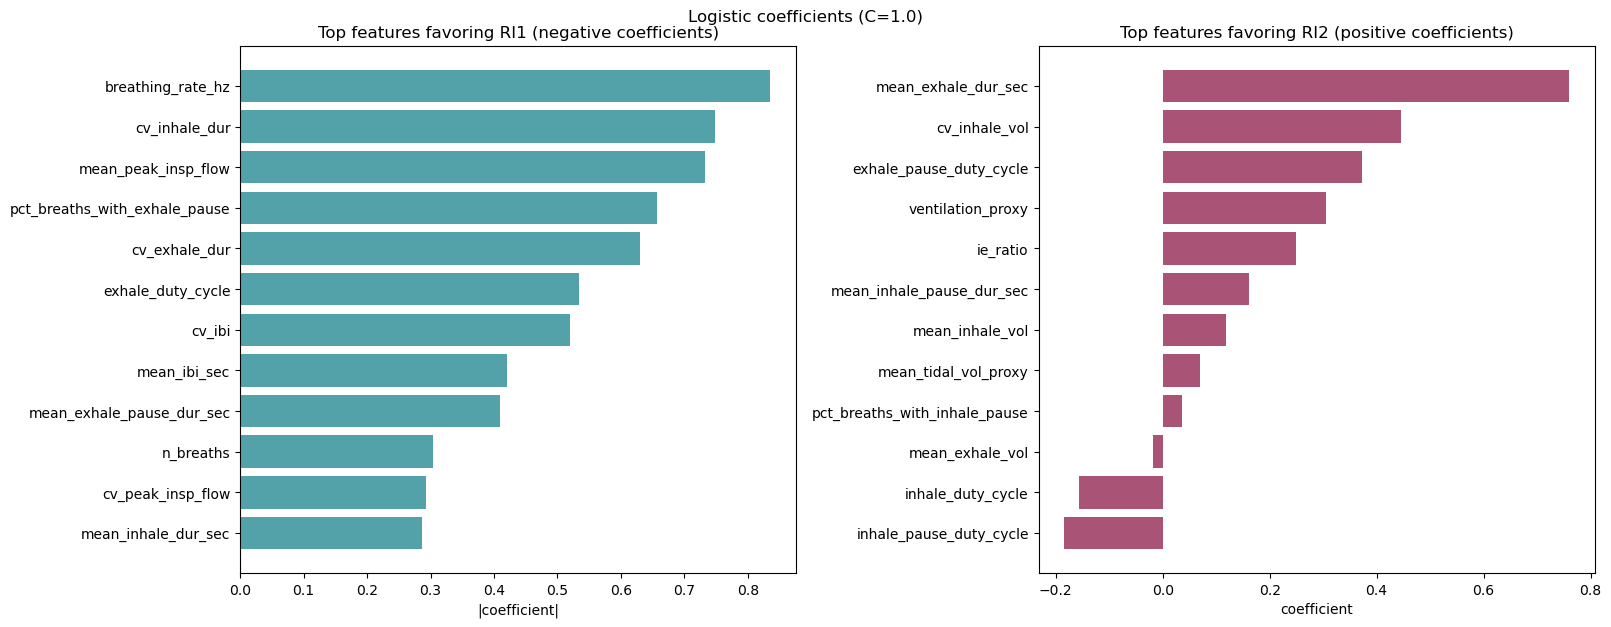

In [16]:
# Coefficient importance (RI1 vs RI2) + per-mouse LOSO performance
from collections import Counter
from sklearn.base import clone
from sklearn.metrics import balanced_accuracy_score, f1_score
from sklearn.model_selection import LeaveOneGroupOut

if "X" not in globals() or "y" not in globals() or "groups" not in globals():
    raise ValueError("Run the feature/preprocessing cells first so X, y, and groups are available.")

# ---------------------------------------------------------------------
# 1) Build a single logistic model for coefficient interpretation
#    Use most common best C from nested search when available.
# ---------------------------------------------------------------------
def _best_c_from_nested(default_c=1.0):
    if "nested_results" not in globals() or "LogisticRegression" not in nested_results:
        return default_c
    rows = nested_results["LogisticRegression"].get("best_params_per_mouse", [])
    c_vals = []
    for r in rows:
        bp = r.get("best_params", {})
        if "model__C" in bp:
            c_vals.append(bp["model__C"])
    if not c_vals:
        return default_c
    return Counter(c_vals).most_common(1)[0][0]

best_c = _best_c_from_nested(default_c=1.0)
coef_model = Pipeline([
    ("preprocess", preprocess_numeric),
    (
        "model",
        LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            solver="lbfgs",
            C=best_c,
            random_state=42,
        ),
    ),
])
coef_model.fit(X, y)

lr = coef_model.named_steps["model"]
if lr.coef_.shape[0] != 1:
    raise ValueError("This plotting cell expects binary logistic regression.")

coef = pd.Series(lr.coef_[0], index=X.columns)
class0, class1 = lr.classes_[0], lr.classes_[1]

# Positive weights push toward class1; negative push toward class0.
top_n = 12
ri2_top = coef.sort_values(ascending=False).head(top_n)
ri1_top = coef.sort_values(ascending=True).head(top_n)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

axes[0].barh(ri1_top.index[::-1], np.abs(ri1_top.values[::-1]), color="#53A1A9")
axes[0].set_title(f"Top features favoring {class0} (negative coefficients)")
axes[0].set_xlabel("|coefficient|")

axes[1].barh(ri2_top.index[::-1], ri2_top.values[::-1], color="#A95376")
axes[1].set_title(f"Top features favoring {class1} (positive coefficients)")
axes[1].set_xlabel("coefficient")

plt.suptitle(f"Logistic coefficients (C={best_c})", y=1.02)
plt.show()

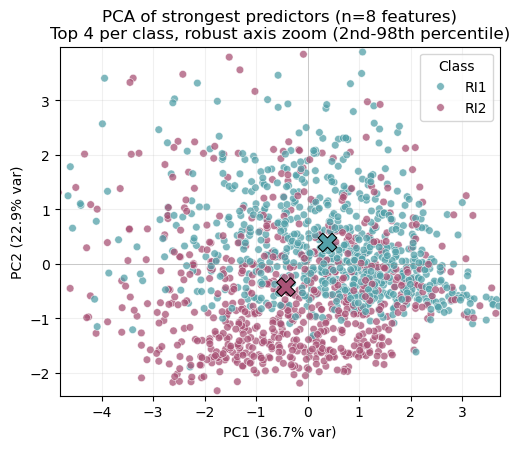

Top-feature union used for PCA:


0                breathing_rate_hz
1                    cv_inhale_dur
2              mean_peak_insp_flow
3    pct_breaths_with_exhale_pause
4              mean_exhale_dur_sec
5                    cv_inhale_vol
6          exhale_pause_duty_cycle
7                ventilation_proxy
Name: feature, dtype: object

Note: PCA is centered by design; zero is the transformed mean, not a raw feature value.


In [17]:
# Geometric separation view of top RI1/RI2 predictors (PCA on top-weighted features)
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

required = ["ri1_top", "ri2_top", "X", "y", "class0", "class1"]
missing = [k for k in required if k not in globals()]
if missing:
    raise ValueError(f"Run the coefficient-importance cell first; missing: {missing}")

# Use only the strongest predictors per class to reduce overlap.
# Change to 3 if you want an even tighter view.
top_per_class = 4
ri1_top_small = coef.sort_values(ascending=True).head(top_per_class)
ri2_top_small = coef.sort_values(ascending=False).head(top_per_class)
top_feature_union = list(dict.fromkeys(list(ri1_top_small.index) + list(ri2_top_small.index)))
X_top = X[top_feature_union].copy()

# Match the model-prep idea: impute then z-score before PCA.
X_top_imputed = SimpleImputer(strategy="median").fit_transform(X_top)
X_top_scaled = StandardScaler().fit_transform(X_top_imputed)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_top_scaled)

pca_df = pd.DataFrame(
    {
        "PC1": X_pca[:, 0],
        "PC2": X_pca[:, 1],
        "label": y.astype(str).values,
    }
)

fig, ax = plt.subplots(figsize=(5.2, 4.6))
palette = {str(class0): "#53A1A9", str(class1): "#A95376"}

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="label",
    hue_order=[str(class0), str(class1)],
    palette=palette,
    alpha=0.75,
    s=30,
    ax=ax,
)

# Add class centroids for a clearer separation cue.
centroids = pca_df.groupby("label")[['PC1', 'PC2']].mean().reset_index()
sns.scatterplot(
    data=centroids,
    x="PC1",
    y="PC2",
    hue="label",
    hue_order=[str(class0), str(class1)],
    palette=palette,
    marker="X",
    s=180,
    edgecolor="black",
    linewidth=0.8,
    legend=False,
    ax=ax,
)

# Robust zoom: ignore extreme tails so outliers do not dominate axis range.
q_lo, q_hi = 0.02, 0.98
x_lo, x_hi = pca_df["PC1"].quantile([q_lo, q_hi])
y_lo, y_hi = pca_df["PC2"].quantile([q_lo, q_hi])
x_pad = max(0.25, 0.1 * (x_hi - x_lo))
y_pad = max(0.25, 0.1 * (y_hi - y_lo))
ax.set_xlim(x_lo - x_pad, x_hi + x_pad)
ax.set_ylim(y_lo - y_pad, y_hi + y_pad)

ax.axhline(0, color="gray", lw=0.7, alpha=0.35)
ax.axvline(0, color="gray", lw=0.7, alpha=0.35)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
ax.set_title(
    f"PCA of strongest predictors (n={len(top_feature_union)} features)\n"
    f"Top {top_per_class} per class, robust axis zoom (2nd-98th percentile)"
)
ax.legend(title="Class", loc="best", frameon=True)
ax.grid(alpha=0.18)
plt.tight_layout()
plt.show()

print("Top-feature union used for PCA:")
display(pd.Series(top_feature_union, name="feature"))
print("Note: PCA is centered by design; zero is the transformed mean, not a raw feature value.")

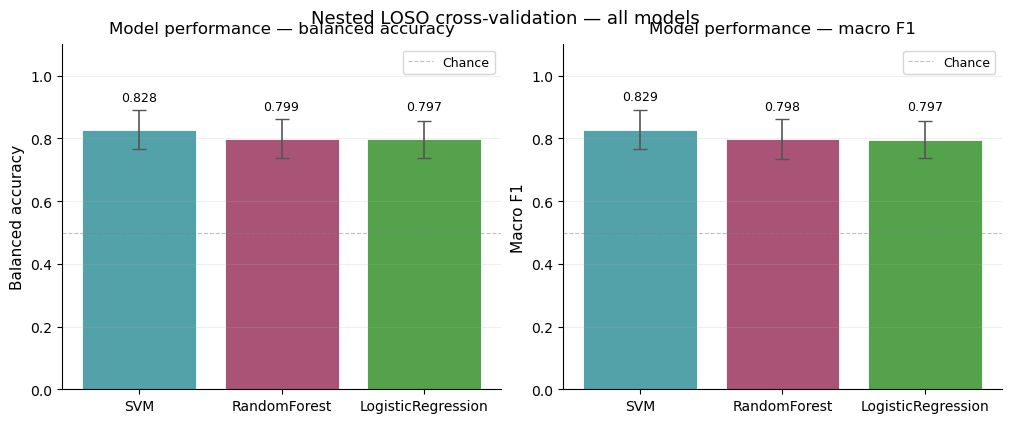

In [18]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

models   = nested_results_df.index.tolist()
bal_acc  = nested_results_df["mean_balanced_accuracy"].values
bal_std  = nested_results_df["std_balanced_accuracy"].values
mac_f1   = nested_results_df["mean_macro_f1"].values
mac_std  = nested_results_df["std_macro_f1"].values

colors = ["#53A1A9", "#A95376", "#54A24B"][:len(models)]
x = np.arange(len(models))

for ax, means, stds, ylabel, title in [
    (axes[0], bal_acc, bal_std, "Balanced accuracy", "Model performance — balanced accuracy"),
    (axes[1], mac_f1,  mac_std, "Macro F1",          "Model performance — macro F1"),
]:
    bars = ax.bar(x, means, yerr=stds, capsize=5,
                  color=colors, edgecolor="white", linewidth=0.6,
                  error_kw=dict(elinewidth=1.2, ecolor="#555"))
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_ylim(0, 1.1)
    ax.axhline(0.5, color="gray", linewidth=0.8, linestyle="--", alpha=0.5, label="Chance")
    ax.legend(fontsize=9)
    ax.set_title(title, fontsize=12, pad=8)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.2)
    for bar, m in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(stds) + 0.02,
                f"{m:.3f}", ha="center", va="bottom", fontsize=9)

plt.suptitle("Nested LOSO cross-validation — all models", fontsize=13, y=1.02)
plt.savefig("panel_A_model_performance.svg", bbox_inches="tight")
plt.show()

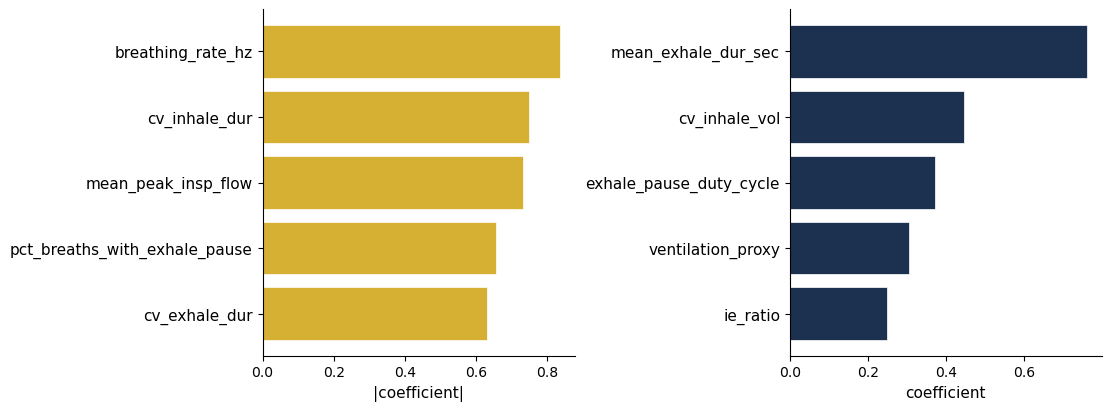

In [19]:
# ================================
# CLEAN FEATURE IMPORTANCE PLOT
# ================================

import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# --- color palette (consistent with whisker plot) ---
rank_palette = {
    "Dominant": (28/255, 48/255, 79/255),     # navy (RI2)
    "Subordinate": (213/255, 176/255, 50/255) # mustard (RI1)
}

# --- best C from nested CV ---
def _best_c(default=1.0):
    if "nested_results" not in globals() or "LogisticRegression" not in nested_results:
        return default
    c_vals = [
        r["best_params"]["model__C"]
        for r in nested_results["LogisticRegression"].get("best_params_per_mouse", [])
        if "model__C" in r.get("best_params", {})
    ]
    return Counter(c_vals).most_common(1)[0][0] if c_vals else default

best_c = _best_c()

# --- fit model ---
coef_pipe = Pipeline([
    ("preprocess", preprocess_numeric),
    ("model", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        solver="lbfgs",
        C=best_c,
        random_state=42
    )),
])

coef_pipe.fit(X, y)

lr = coef_pipe.named_steps["model"]
coef = pd.Series(lr.coef_[0], index=X.columns)

class0, class1 = lr.classes_  # expect RI1, RI2

# --- select top features ---
TOP_N = 5
ri1_top = coef.sort_values().head(TOP_N)                  # favors RI1 (Subordinate)
ri2_top = coef.sort_values(ascending=False).head(TOP_N)   # favors RI2 (Dominant)

# --- plotting ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

# ---- RI1 (Subordinate) ----
axes[0].barh(
    range(TOP_N),
    np.abs(ri1_top.values[::-1]),
    color=rank_palette["Subordinate"],
    edgecolor="white",
    linewidth=0.5
)
axes[0].set_yticks(range(TOP_N))
axes[0].set_yticklabels(ri1_top.index[::-1], fontsize=11)
axes[0].set_xlabel("|coefficient|", fontsize=11)

# ---- RI2 (Dominant) ----
axes[1].barh(
    range(TOP_N),
    ri2_top.values[::-1],
    color=rank_palette["Dominant"],
    edgecolor="white",
    linewidth=0.5
)
axes[1].set_yticks(range(TOP_N))
axes[1].set_yticklabels(ri2_top.index[::-1], fontsize=11)
axes[1].set_xlabel("coefficient", fontsize=11)

# --- clean styling (match whisker plot look) ---
for ax in axes:
    ax.grid(False)                         # remove gridlines
    ax.set_facecolor("white")              # clean white background
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# --- save + show ---
plt.savefig("panel_C_feature_importance.svg", bbox_inches="tight")
plt.show()

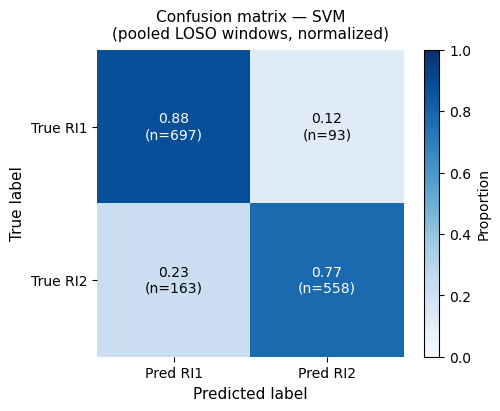

In [20]:
from sklearn.metrics import confusion_matrix
import matplotlib.colors as mcolors

# Uses pooled predictions already stored in nested_results
# Default to best model by balanced accuracy
best_model_name = nested_results_df.index[0]
y_true = nested_results[best_model_name]["y_true_all"]
y_pred = nested_results[best_model_name]["y_pred_all"]
classes = np.sort(np.unique(y_true))

cm_raw  = confusion_matrix(y_true, y_pred, labels=classes)
cm_norm = cm_raw.astype(float) / cm_raw.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(5, 4), constrained_layout=True)
im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.046, label="Proportion")

for i in range(len(classes)):
    for j in range(len(classes)):
        color = "white" if cm_norm[i, j] > 0.6 else "black"
        ax.text(j, i, f"{cm_norm[i,j]:.2f}\n(n={cm_raw[i,j]})",
                ha="center", va="center", fontsize=10, color=color)

ax.set_xticks(range(len(classes)))
ax.set_yticks(range(len(classes)))
ax.set_xticklabels([f"Pred {c}" for c in classes], fontsize=10)
ax.set_yticklabels([f"True {c}" for c in classes], fontsize=10)
ax.set_xlabel("Predicted label", fontsize=11)
ax.set_ylabel("True label", fontsize=11)
ax.set_title(f"Confusion matrix — {best_model_name}\n(pooled LOSO windows, normalized)",
             fontsize=11, pad=8)
ax.spines[["top", "right", "bottom", "left"]].set_visible(False)

plt.savefig("panel_D_confusion_matrix.svg", bbox_inches="tight")
plt.show()

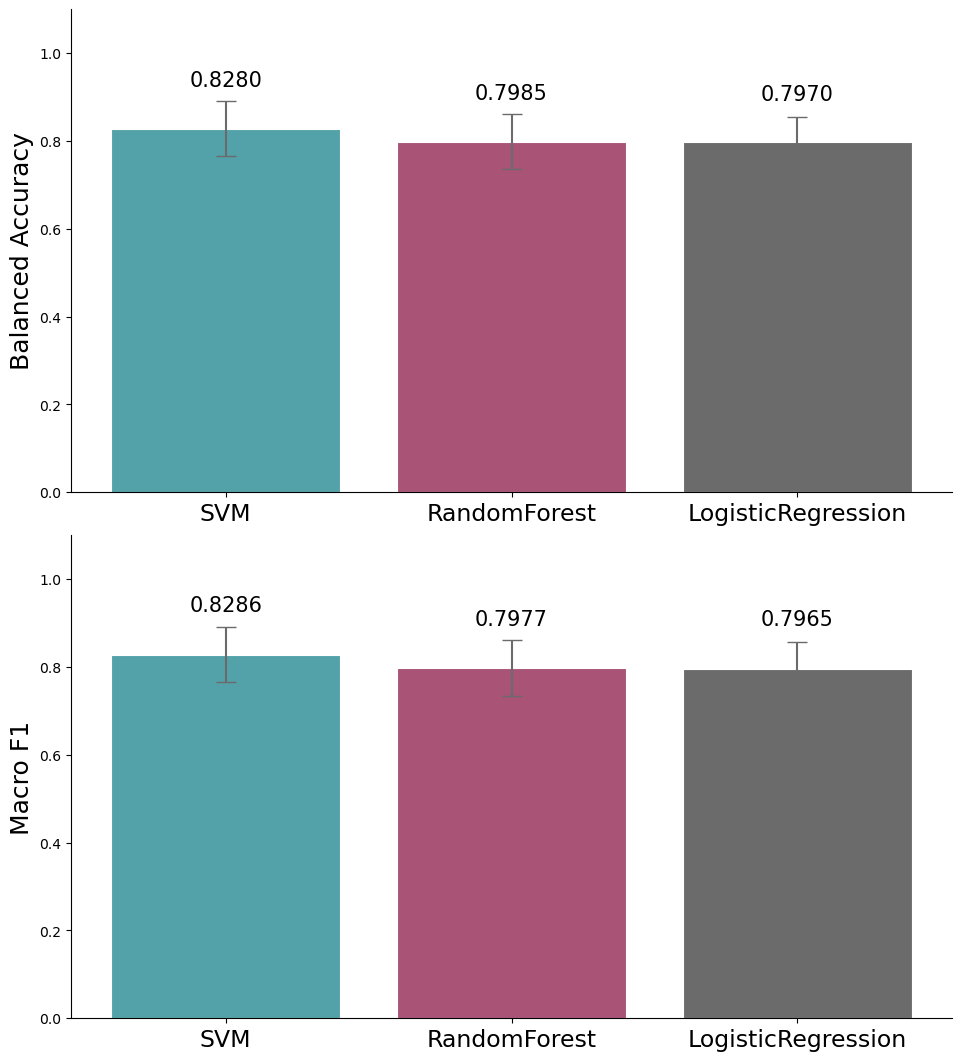

In [21]:
# ==========================================
# PANEL A — MODEL PERFORMANCE (FINAL MATCHED SIZE)
# ==========================================

import matplotlib.pyplot as plt
import numpy as np

# Same palette as Panel C
BLUE         = "#53A1A9"
PURPLE_PINK  = "#A95376"
GRAY         = "#6B6B6B"

# --- KEEP ORIGINAL HEIGHT ---
fig, axes = plt.subplots(2, 1, figsize=(9.5, 10.5), constrained_layout=True)
fig.patch.set_alpha(0)

models   = nested_results_df.index.tolist()
bal_acc  = nested_results_df["mean_balanced_accuracy"].values
bal_std  = nested_results_df["std_balanced_accuracy"].values
mac_f1   = nested_results_df["mean_macro_f1"].values
mac_std  = nested_results_df["std_macro_f1"].values

# First = blue, second = pink, rest = gray
base_colors = [BLUE, PURPLE_PINK]
colors = base_colors + [GRAY] * max(0, len(models) - len(base_colors))
colors = colors[:len(models)]

x = np.arange(len(models))

for ax, means, stds, ylabel in [
    (axes[0], bal_acc, bal_std, "Balanced Accuracy"),
    (axes[1], mac_f1,  mac_std, "Macro F1"),
]:
    ax.set_facecolor("none")

    bars = ax.bar(
        x,
        means,
        yerr=stds,
        capsize=7,
        color=colors,
        edgecolor="white",
        linewidth=0.8,
        error_kw=dict(elinewidth=1.5, ecolor=GRAY)
    )

    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=17)
    ax.set_ylabel(ylabel, fontsize=18)
    ax.set_ylim(0, 1.1)

    # Clean look (match Panel C)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(False)

    # Value labels
    y_pad = max(stds) + 0.025
    for bar, m in zip(bars, means):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + y_pad,
            f"{m:.4f}",
            ha="center",
            va="bottom",
            fontsize=15
        )

plt.savefig("panel_A.svg", bbox_inches="tight", transparent=True)
plt.show()

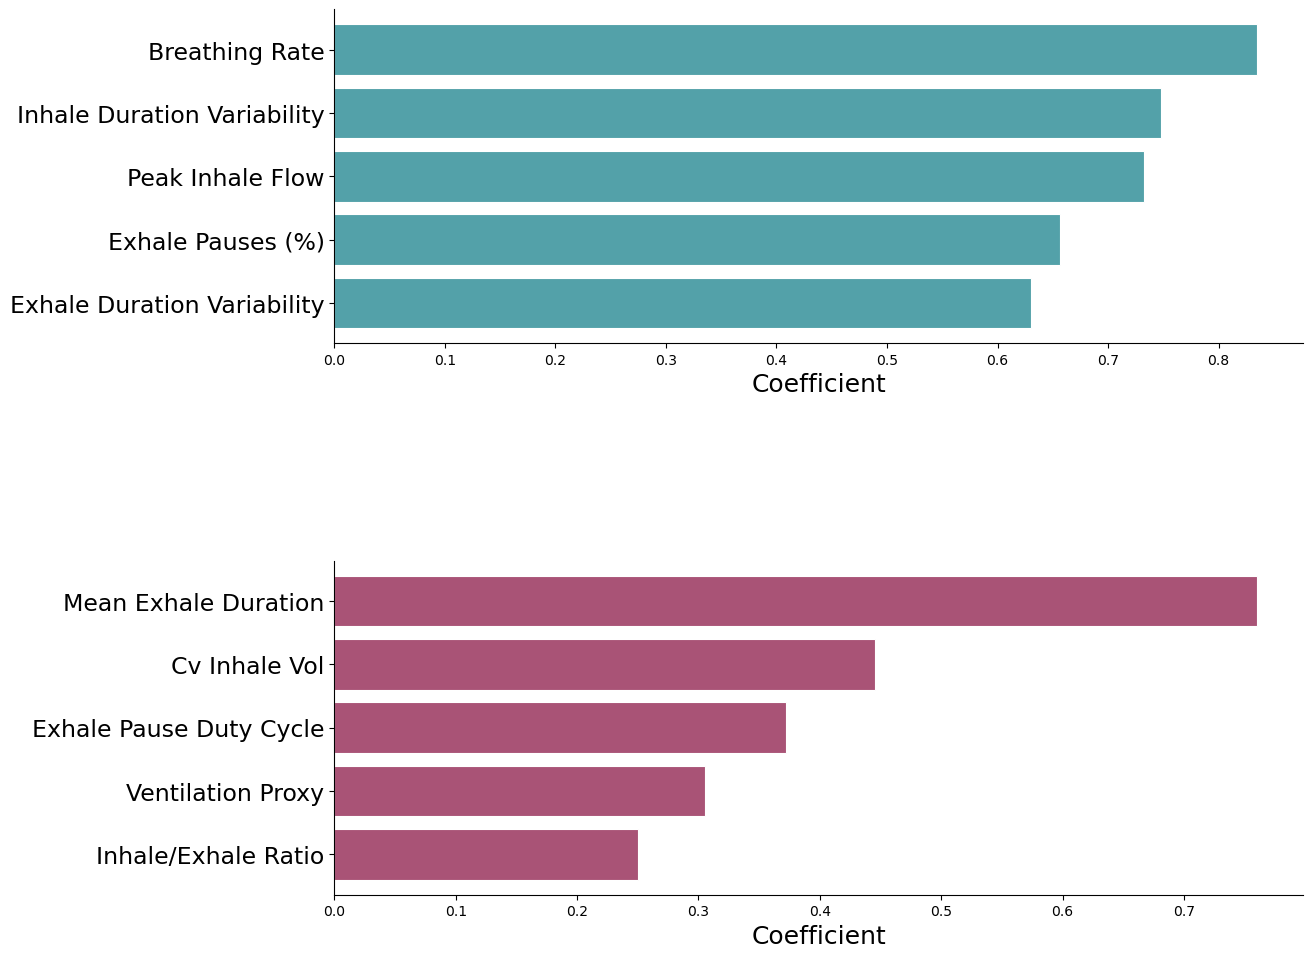

In [22]:
# ==========================================
# PANEL C — TOP FEATURES (FINAL)
# ==========================================

from collections import Counter
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Same palette as Panel A (RI1 = teal, RI2 = pink)
BLUE         = "#53A1A9"
PURPLE_PINK  = "#A95376"
GRAY         = "#6B6B6B"

# Pick best C from nested search
def _best_c(default=1.0):
    if "nested_results" not in globals() or "LogisticRegression" not in nested_results:
        return default
    c_vals = [
        r["best_params"]["model__C"]
        for r in nested_results["LogisticRegression"].get("best_params_per_mouse", [])
        if "model__C" in r.get("best_params", {})
    ]
    return Counter(c_vals).most_common(1)[0][0] if c_vals else default

best_c = _best_c()

coef_pipe = Pipeline([
    ("preprocess", preprocess_numeric),
    ("model", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        solver="lbfgs",
        C=best_c,
        random_state=42
    )),
])

coef_pipe.fit(X, y)

lr = coef_pipe.named_steps["model"]
coef = pd.Series(lr.coef_[0], index=X.columns)

TOP_N = 5
ri1_top = coef.sort_values().head(TOP_N)
ri2_top = coef.sort_values(ascending=False).head(TOP_N)

# Feature name cleanup
feature_name_map = {
    "n_breaths": "Breath Count",
    "breathing_rate_hz": "Breathing Rate",
    "mean_ibi_sec": "Time Between Breaths",
    "cv_breathing_rate": "Breathing Rate Variability",
    "mean_inhale_dur_sec": "Mean Inhale Duration",
    "cv_inhale_dur": "Inhale Duration Variability",
    "mean_exhale_dur_sec": "Mean Exhale Duration",
    "cv_exhale_dur": "Exhale Duration Variability",
    "ie_ratio": "Inhale/Exhale Ratio",
    "mean_peak_insp_flow": "Peak Inhale Flow",
    "mean_peak_exp_flow": "Peak Exhale Flow",
    "cv_peak_insp_flow": "Inhale Flow Variability",
    "mean_inhale_vol": "Mean Inhale Volume",
    "mean_exhale_vol": "Mean Exhale Volume",
    "mean_tidal_vol": "Mean Tidal Volume",
    "cv_tidal_vol": "Tidal Volume Variability",
    "minute_ventilation": "Minute Ventilation",
    "pct_breaths_with_inhale_pause": "Inhale Pauses (%)",
    "mean_inhale_pause_dur_sec": "Mean Inhale Pause",
    "cv_inhale_pause_dur": "Inhale Pause Variability",
    "inhale_pause_duty_cycle": "Inhale Pause Duty Cycle",
    "pct_breaths_with_exhale_pause": "Exhale Pauses (%)",
    "mean_exhale_pause_dur_sec": "Mean Exhale Pause",
    "cv_exhale_pause_dur": "Exhale Pause Variability",
    "exhale_pause_duty_cycle": "Exhale Pause Duty Cycle",
    "inhale_duty_cycle": "Inhale Duty Cycle",
    "exhale_duty_cycle": "Exhale Duty Cycle",
}

def pretty_name(name):
    return feature_name_map.get(name, name.replace("_", " ").title())

ri1_labels = [pretty_name(x) for x in ri1_top.index[::-1]]
ri2_labels = [pretty_name(x) for x in ri2_top.index[::-1]]

fig, axes = plt.subplots(2, 1, figsize=(12.5, 11.5))
fig.patch.set_alpha(0)
fig.subplots_adjust(hspace=0.65)

# RI1 (blue)
axes[0].set_facecolor("none")
axes[0].barh(
    range(TOP_N),
    np.abs(ri1_top.values[::-1]),
    color=BLUE,
    edgecolor="white",
    linewidth=0.8
)
axes[0].set_yticks(range(TOP_N))
axes[0].set_yticklabels(ri1_labels, fontsize=17)
axes[0].set_xlabel("Coefficient", fontsize=18)
axes[0].set_ylabel("")
axes[0].spines[["top", "right"]].set_visible(False)

# RI2 (purplish pink)
axes[1].set_facecolor("none")
axes[1].barh(
    range(TOP_N),
    ri2_top.values[::-1],
    color=PURPLE_PINK,
    edgecolor="white",
    linewidth=0.8
)
axes[1].set_yticks(range(TOP_N))
axes[1].set_yticklabels(ri2_labels, fontsize=17)
axes[1].set_xlabel("Coefficient", fontsize=18)
axes[1].set_ylabel("")
axes[1].spines[["top", "right"]].set_visible(False)

plt.savefig("panel_C.svg", bbox_inches="tight", transparent=True)
plt.show()

In [23]:
# ==========================================
# FINAL OUTER-LOOP REPORT (NESTED LOSO)
# ==========================================
# This reports the true held-out-mouse performance from the OUTER loop.
# It does NOT use the inner GridSearchCV score as the final result.

import numpy as np
import pandas as pd
from scipy import stats
from IPython.display import display

if "nested_results" not in globals() or len(nested_results) == 0:
    raise ValueError("Run the nested LOSO search cell first so nested_results exists.")

# ------------------------------------------------------------
# 1) Reconstruct per-fold OUTER test results from nested_results
# ------------------------------------------------------------
rows = []
for model_name, vals in nested_results.items():
    for r in vals.get("best_params_per_mouse", []):
        # These are the OUTER-loop test metrics for the held-out mouse
        rows.append({
            "Model": model_name,
            "HeldOutMouse": str(r.get("held_out_mouse")),
            "n_test_windows": int(r.get("n_test_windows", np.nan)),
            "outer_balanced_accuracy": float(r.get("test_balanced_accuracy", np.nan)),
            "outer_macro_f1": float(r.get("test_macro_f1", np.nan)),
            "flip_balanced_accuracy": float(r.get("flip_balanced_accuracy", np.nan)),
            "flip_macro_f1": float(r.get("flip_macro_f1", np.nan)),
            "inner_best_cv_balanced_accuracy": float(r.get("best_inner_cv_score", np.nan)),
            "best_params": r.get("best_params", {}),
        })

outer_folds_df = pd.DataFrame(rows)

if outer_folds_df.empty:
    raise ValueError("No per-fold outer results found. Check nested_results['...']['best_params_per_mouse'].")

print("=" * 90)
print("Per-fold OUTER test results (each row = one held-out mouse)")
print("=" * 90)
display(
    outer_folds_df.sort_values(["Model", "HeldOutMouse"])[[
        "Model",
        "HeldOutMouse",
        "n_test_windows",
        "outer_balanced_accuracy",
        "outer_macro_f1",
        "inner_best_cv_balanced_accuracy",
        "best_params"
    ]]
)

# ------------------------------------------------------------
# 2) Aggregate OUTER-loop metrics across held-out mice
# ------------------------------------------------------------
def _ci95(x):
    x = pd.Series(x).dropna().astype(float)
    n = len(x)
    if n < 2:
        return (np.nan, np.nan)
    mean = x.mean()
    sem = stats.sem(x)
    lo, hi = stats.t.interval(0.95, df=n - 1, loc=mean, scale=sem)
    return (lo, hi)

summary_rows = []
for model_name, d in outer_folds_df.groupby("Model", sort=False):
    bal = d["outer_balanced_accuracy"].dropna().astype(float)
    f1  = d["outer_macro_f1"].dropna().astype(float)

    bal_ci_lo, bal_ci_hi = _ci95(bal)
    f1_ci_lo, f1_ci_hi   = _ci95(f1)

    summary_rows.append({
        "Model": model_name,
        "n_outer_folds": int(len(d)),
        "mean_balanced_accuracy": bal.mean(),
        "std_balanced_accuracy": bal.std(ddof=0),   # matches your current notebook summary convention
        "mean_macro_f1": f1.mean(),
        "std_macro_f1": f1.std(ddof=0),
        "bal_acc_ci95_low": bal_ci_lo,
        "bal_acc_ci95_high": bal_ci_hi,
        "macro_f1_ci95_low": f1_ci_lo,
        "macro_f1_ci95_high": f1_ci_hi,
    })

outer_summary_df = (
    pd.DataFrame(summary_rows)
    .sort_values("mean_balanced_accuracy", ascending=False)
    .reset_index(drop=True)
)

print("\n" + "=" * 90)
print("FINAL MODEL RESULTS TO REPORT (OUTER LOOP ONLY)")
print("=" * 90)
display(outer_summary_df)

# ------------------------------------------------------------
# 3) Pick best model by OUTER balanced accuracy and print clean report
# ------------------------------------------------------------
best_model_name = outer_summary_df.loc[0, "Model"]
best_row = outer_summary_df.iloc[0]

print("\n" + "=" * 90)
print("BEST MODEL (selected by OUTER mean balanced accuracy)")
print("=" * 90)
print(f"Best model: {best_model_name}")
print(f"Outer folds (held-out mice): {int(best_row['n_outer_folds'])}")
print(
    f"Balanced Accuracy: {best_row['mean_balanced_accuracy']:.4f} "
    f"+/- {best_row['std_balanced_accuracy']:.4f} "
    f"(95% CI {best_row['bal_acc_ci95_low']:.4f} to {best_row['bal_acc_ci95_high']:.4f})"
)
print(
    f"Macro F1:          {best_row['mean_macro_f1']:.4f} "
    f"+/- {best_row['std_macro_f1']:.4f} "
    f"(95% CI {best_row['macro_f1_ci95_low']:.4f} to {best_row['macro_f1_ci95_high']:.4f})"
)

# ------------------------------------------------------------
# 4) Poster/paper-ready text block
# ------------------------------------------------------------
report_text = (
    f"{best_model_name} achieved a mean outer-loop balanced accuracy of "
    f"{best_row['mean_balanced_accuracy']:.3f} +/- {best_row['std_balanced_accuracy']:.3f} "
    f"and a mean outer-loop macro F1 of "
    f"{best_row['mean_macro_f1']:.3f} +/- {best_row['std_macro_f1']:.3f} "
    f"across {int(best_row['n_outer_folds'])} leave-one-subject-out folds."
)

print("\nPoster/paper sentence:")
print(report_text)

# ------------------------------------------------------------
# 5) Optional: save outputs for later plotting/reporting
# ------------------------------------------------------------
final_outer_folds_df = outer_folds_df.copy()
final_outer_summary_df = outer_summary_df.copy()
final_best_model_name = best_model_name

Per-fold OUTER test results (each row = one held-out mouse)


,Model,HeldOutMouse,n_test_windows,outer_balanced_accuracy,outer_macro_f1,inner_best_cv_balanced_accuracy,best_params
0,LogisticRegression,1_1,200,0.830000,0.829728,0.772382,{'model__C': 0.01}
1,LogisticRegression,1_2,187,0.702095,0.698113,0.802520,{'model__C': 0.01}
2,LogisticRegression,2_3,193,0.744200,0.741421,0.792599,{'model__C': 0.01}
3,LogisticRegression,2_4,182,0.874146,0.880184,0.783730,{'model__C': 1.0}
4,LogisticRegression,3_5,171,0.772324,0.768091,0.802903,{'model__C': 10.0}
5,LogisticRegression,3_6,183,0.761325,0.763711,0.799831,{'model__C': 1.0}
6,LogisticRegression,4_7,200,0.820000,0.819114,0.788493,{'model__C': 1.0}
7,LogisticRegression,4_8,195,0.872001,0.871795,0.782292,{'model__C': 1.0}
16,RandomForest,1_1,200,0.850000,0.849760,0.773237,"{'model__max_depth': None, 'model__max_feature..."
17,RandomForest,1_2,187,0.680689,0.676157,0.814759,"{'model__max_depth': None, 'model__max_feature..."



FINAL MODEL RESULTS TO REPORT (OUTER LOOP ONLY)


,Model,n_outer_folds,mean_balanced_accuracy,std_balanced_accuracy,mean_macro_f1,std_macro_f1,bal_acc_ci95_low,bal_acc_ci95_high,macro_f1_ci95_low,macro_f1_ci95_high
0,SVM,8,0.827971,0.062245,0.828570,0.062807,0.772339,0.883602,0.772437,0.884704
1,RandomForest,8,0.798500,0.062293,0.797733,0.064408,0.742826,0.854174,0.740169,0.855297
2,LogisticRegression,8,0.797011,0.057956,0.796520,0.060087,0.745214,0.848809,0.742817,0.850222



BEST MODEL (selected by OUTER mean balanced accuracy)
Best model: SVM
Outer folds (held-out mice): 8
Balanced Accuracy: 0.8280 +/- 0.0622 (95% CI 0.7723 to 0.8836)
Macro F1:          0.8286 +/- 0.0628 (95% CI 0.7724 to 0.8847)

Poster/paper sentence:
SVM achieved a mean outer-loop balanced accuracy of 0.828 +/- 0.062 and a mean outer-loop macro F1 of 0.829 +/- 0.063 across 8 leave-one-subject-out folds.


## Geometric Structure In Model-Informed Space

This section focuses on interpretable geometry rather than clustering all windows in full feature space.

Plan:
1. Build a model-informed feature subset (top absolute logistic coefficients).
2. Visualize window-level structure in PCA space with class centroids and covariance ellipses.
3. Cluster in reduced space (PCA) and score alignment with true valence labels.
4. Reduce mouse noise by aggregating to mouse x valence prototypes, then cluster prototypes.

Key idea: overlap is expected in biology. We look for consistent directional structure, centroid shifts, and improved separation after aggregation.

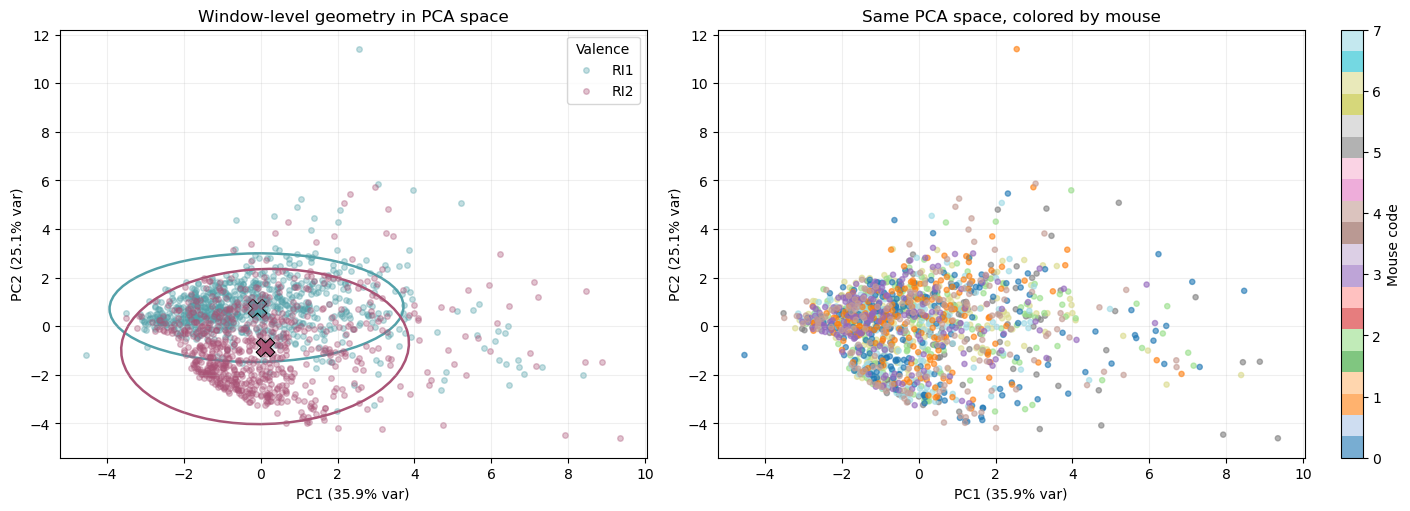

c:\Users\thoma\miniconda3\envs\biopipeline-env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
c:\Users\thoma\miniconda3\envs\biopipeline-env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


Window-level clustering agreement with valence labels


,method,ARI,NMI,silhouette
0,AgglomerativeWard_on_PCA2,0.209825,0.158544,0.299300
1,KMeans_on_PCA2,0.003695,0.007869,0.413125
2,GMM_full_on_PCA2,0.000286,0.003955,0.429786


c:\Users\thoma\miniconda3\envs\biopipeline-env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\thoma\miniconda3\envs\biopipeline-env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


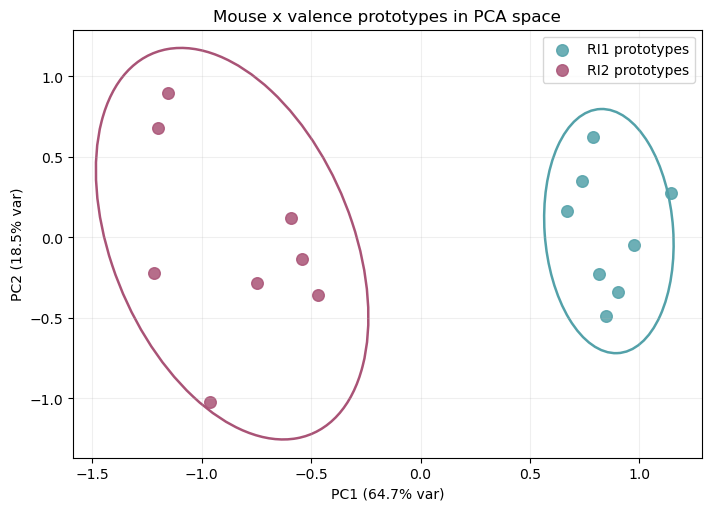

Prototype-level clustering agreement with valence labels


,method,ARI,NMI,silhouette
0,KMeans_on_prototypes_PCA2,1.0,1.0,0.624375
1,GMM_on_prototypes_PCA2,1.0,1.0,0.624375


Practical recommendation
Best window-level method: AgglomerativeWard_on_PCA2 (ARI=0.210, NMI=0.159)
Best prototype-level method: KMeans_on_prototypes_PCA2 (ARI=1.000, NMI=1.000)
Use prototype-level (mouse x valence) clustering for cleaner interpretation, and window-level PCA only as secondary context.


In [ ]:
# Geometric + clustering diagnostics in model-informed space
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score

# Avoid known Windows MKL warning/noise for small KMeans jobs
os.environ.setdefault("OMP_NUM_THREADS", "1")

# ---------- 1) Use top model-informed features ----------
if "coef" not in globals():
    # Fallback: fit a logistic model if coefficient vector is not currently in memory
    from sklearn.pipeline import Pipeline
    from sklearn.linear_model import LogisticRegression
    from collections import Counter

    def _best_c_for_geo(default=1.0):
        if "nested_results" not in globals() or "LogisticRegression" not in nested_results:
            return default
        c_vals = [
            r["best_params"].get("model__C")
            for r in nested_results["LogisticRegression"].get("best_params_per_mouse", [])
            if "model__C" in r.get("best_params", {})
        ]
        return Counter(c_vals).most_common(1)[0][0] if c_vals else default

    geo_pipe = Pipeline([
        ("preprocess", preprocess_numeric),
        ("model", LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            solver="lbfgs",
            C=_best_c_for_geo(),
            random_state=42,
        )),
    ])
    geo_pipe.fit(X, y)
    coef = pd.Series(geo_pipe.named_steps["model"].coef_[0], index=X.columns)

TOPK = 10
top_abs_features = coef.abs().sort_values(ascending=False).head(TOPK).index.tolist()
X_top = X[top_abs_features].copy()

imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()
X_top_z = scaler.fit_transform(imputer.fit_transform(X_top))

# ---------- 2) PCA geometry (window-level) ----------
pca2 = PCA(n_components=2, random_state=42)
Z = pca2.fit_transform(X_top_z)

def _cov_ellipse(xy, ax, n_std=2.0, **kwargs):
    if xy.shape[0] < 3:
        return
    cov = np.cov(xy.T)
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    width, height = 2 * n_std * np.sqrt(np.maximum(vals, 1e-12))
    ell = Ellipse(xy=xy.mean(axis=0), width=width, height=height, angle=angle, fill=False, **kwargs)
    ax.add_patch(ell)

pca_df = pd.DataFrame({
    "PC1": Z[:, 0],
    "PC2": Z[:, 1],
    "valence": y.astype(str).values,
    "mouse": groups.astype(str).values,
})

labels_sorted = sorted(pca_df["valence"].unique())
palette = {
    labels_sorted[0]: "#53A1A9",
    labels_sorted[1]: "#A95376",
}

fig, axes = plt.subplots(1, 1, figsize=(14, 5), constrained_layout=True)

# Left: color by valence, with centroids and ellipses
for lab in labels_sorted:
    d = pca_df[pca_df["valence"] == lab]
    axes[0].scatter(d["PC1"], d["PC2"], s=16, alpha=0.35, color=palette[lab], label=lab)
    c = d[["PC1", "PC2"]].mean().values
    axes[0].scatter([c[0]], [c[1]], s=180, marker="X", color=palette[lab], edgecolor="black", linewidth=0.8)
    _cov_ellipse(d[["PC1", "PC2"]].values, axes[0], n_std=2.0, color=palette[lab], linewidth=1.8)

axes[0].set_title("Window-level geometry in PCA space")
axes[0].set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% var)")
axes[0].set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% var)")
axes[0].legend(title="Valence")
axes[0].grid(alpha=0.2)

plt.colorbar(sc, ax=axes[1], fraction=0.046, label="Mouse code")

plt.savefig("panel_G1_pca_geometry_windows.svg", bbox_inches="tight", transparent=True)
plt.show()

# ---------- 3) Cluster windows in PCA space and score vs true valence ----------
# Encode y to 0/1 for cluster agreement metrics
y_codes = pd.Series(y).astype("category").cat.codes.values

cluster_results = []

# KMeans
km = KMeans(n_clusters=2, random_state=42, n_init=20)
km_lab = km.fit_predict(Z)
cluster_results.append({
    "method": "KMeans_on_PCA2",
    "ARI": adjusted_rand_score(y_codes, km_lab),
    "NMI": normalized_mutual_info_score(y_codes, km_lab),
    "silhouette": silhouette_score(Z, km_lab),
})

# GMM (better if ellipses / overlap)
gmm = GaussianMixture(n_components=2, covariance_type="full", random_state=42)
gmm_lab = gmm.fit_predict(Z)
cluster_results.append({
    "method": "GMM_full_on_PCA2",
    "ARI": adjusted_rand_score(y_codes, gmm_lab),
    "NMI": normalized_mutual_info_score(y_codes, gmm_lab),
    "silhouette": silhouette_score(Z, gmm_lab),
})

# Agglomerative
agg = AgglomerativeClustering(n_clusters=2, linkage="ward")
agg_lab = agg.fit_predict(Z)
cluster_results.append({
    "method": "AgglomerativeWard_on_PCA2",
    "ARI": adjusted_rand_score(y_codes, agg_lab),
    "NMI": normalized_mutual_info_score(y_codes, agg_lab),
    "silhouette": silhouette_score(Z, agg_lab),
})

cluster_results_df = pd.DataFrame(cluster_results).sort_values("ARI", ascending=False).reset_index(drop=True)

print("=" * 90)
print("Window-level clustering agreement with valence labels")
print("=" * 90)
display(cluster_results_df)

# ---------- 4) Mouse-level prototypes (reduce window noise) ----------
proto = (
    pd.DataFrame(X_top_z, columns=top_abs_features)
    .assign(mouse=groups.astype(str).values, valence=y.astype(str).values)
    .groupby(["mouse", "valence"], observed=True)
    .mean()
    .reset_index()
)

proto_X = proto[top_abs_features].values
proto_y_codes = proto["valence"].astype("category").cat.codes.values

pca_proto = PCA(n_components=2, random_state=42)
Zp = pca_proto.fit_transform(proto_X)

km_p = KMeans(n_clusters=2, random_state=42, n_init=20).fit_predict(Zp)
gmm_p = GaussianMixture(n_components=2, covariance_type="full", random_state=42).fit_predict(Zp)

proto_metrics = pd.DataFrame([
    {
        "method": "KMeans_on_prototypes_PCA2",
        "ARI": adjusted_rand_score(proto_y_codes, km_p),
        "NMI": normalized_mutual_info_score(proto_y_codes, km_p),
        "silhouette": silhouette_score(Zp, km_p),
    },
    {
        "method": "GMM_on_prototypes_PCA2",
        "ARI": adjusted_rand_score(proto_y_codes, gmm_p),
        "NMI": normalized_mutual_info_score(proto_y_codes, gmm_p),
        "silhouette": silhouette_score(Zp, gmm_p),
    },
]).sort_values("ARI", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)
for lab in sorted(proto["valence"].unique()):
    d = proto.loc[proto["valence"] == lab]
    dZ = Zp[d.index, :]
    ax.scatter(dZ[:, 0], dZ[:, 1], s=70, alpha=0.85, color=palette[lab], label=f"{lab} prototypes")
    _cov_ellipse(dZ, ax, n_std=2.0, color=palette[lab], linewidth=1.8)

ax.set_title("Mouse x valence prototypes in PCA space")
ax.set_xlabel(f"PC1 ({pca_proto.explained_variance_ratio_[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({pca_proto.explained_variance_ratio_[1]*100:.1f}% var)")
ax.legend()
ax.grid(alpha=0.2)
plt.savefig("panel_G2_pca_geometry_prototypes.svg", bbox_inches="tight", transparent=True)
plt.show()

print("=" * 90)
print("Prototype-level clustering agreement with valence labels")
print("=" * 90)
display(proto_metrics)

# ---------- 5) Recommendation based on metrics ----------
best_window = cluster_results_df.iloc[0]
best_proto = proto_metrics.iloc[0]

print("=" * 90)
print("Practical recommendation")
print("=" * 90)
print(f"Best window-level method: {best_window['method']} (ARI={best_window['ARI']:.3f}, NMI={best_window['NMI']:.3f})")
print(f"Best prototype-level method: {best_proto['method']} (ARI={best_proto['ARI']:.3f}, NMI={best_proto['NMI']:.3f})")
print("Use prototype-level (mouse x valence) clustering for cleaner interpretation, and window-level PCA only as secondary context.")

geo_clustering_artifacts = {
    "top_abs_features": top_abs_features,
    "window_pca_df": pca_df,
    "window_cluster_metrics": cluster_results_df,
    "prototype_table": proto,
    "prototype_cluster_metrics": proto_metrics,
}


Windows dominated by each feature:
  [0] breathing_rate_hz                         n=239 windows (15.8%)
  [1] mean_exhale_dur_sec                       n=163 windows (10.8%)
  [2] cv_inhale_dur                             n=142 windows (9.4%)
  [3] mean_peak_insp_flow                       n=253 windows (16.7%)
  [4] pct_breaths_with_exhale_pause             n=135 windows (8.9%)
  [5] cv_exhale_dur                             n=150 windows (9.9%)
  [6] exhale_duty_cycle                         n=108 windows (7.1%)
  [7] cv_ibi                                    n=148 windows (9.8%)
  [8] cv_inhale_vol                             n=140 windows (9.3%)
  [9] mean_ibi_sec                              n=33 windows (2.2%)


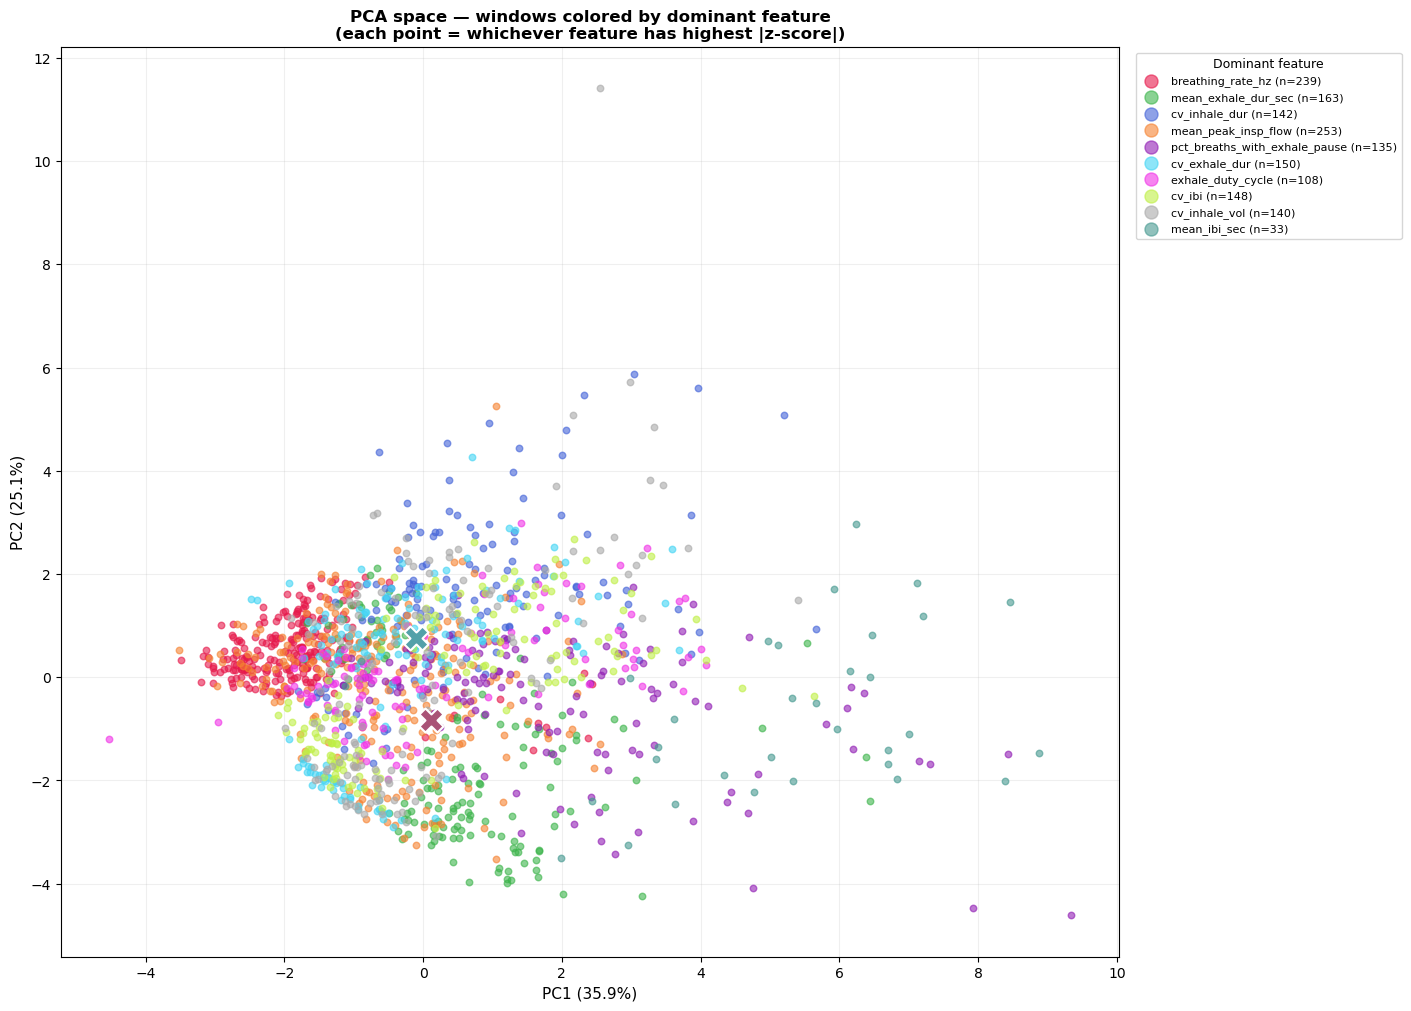

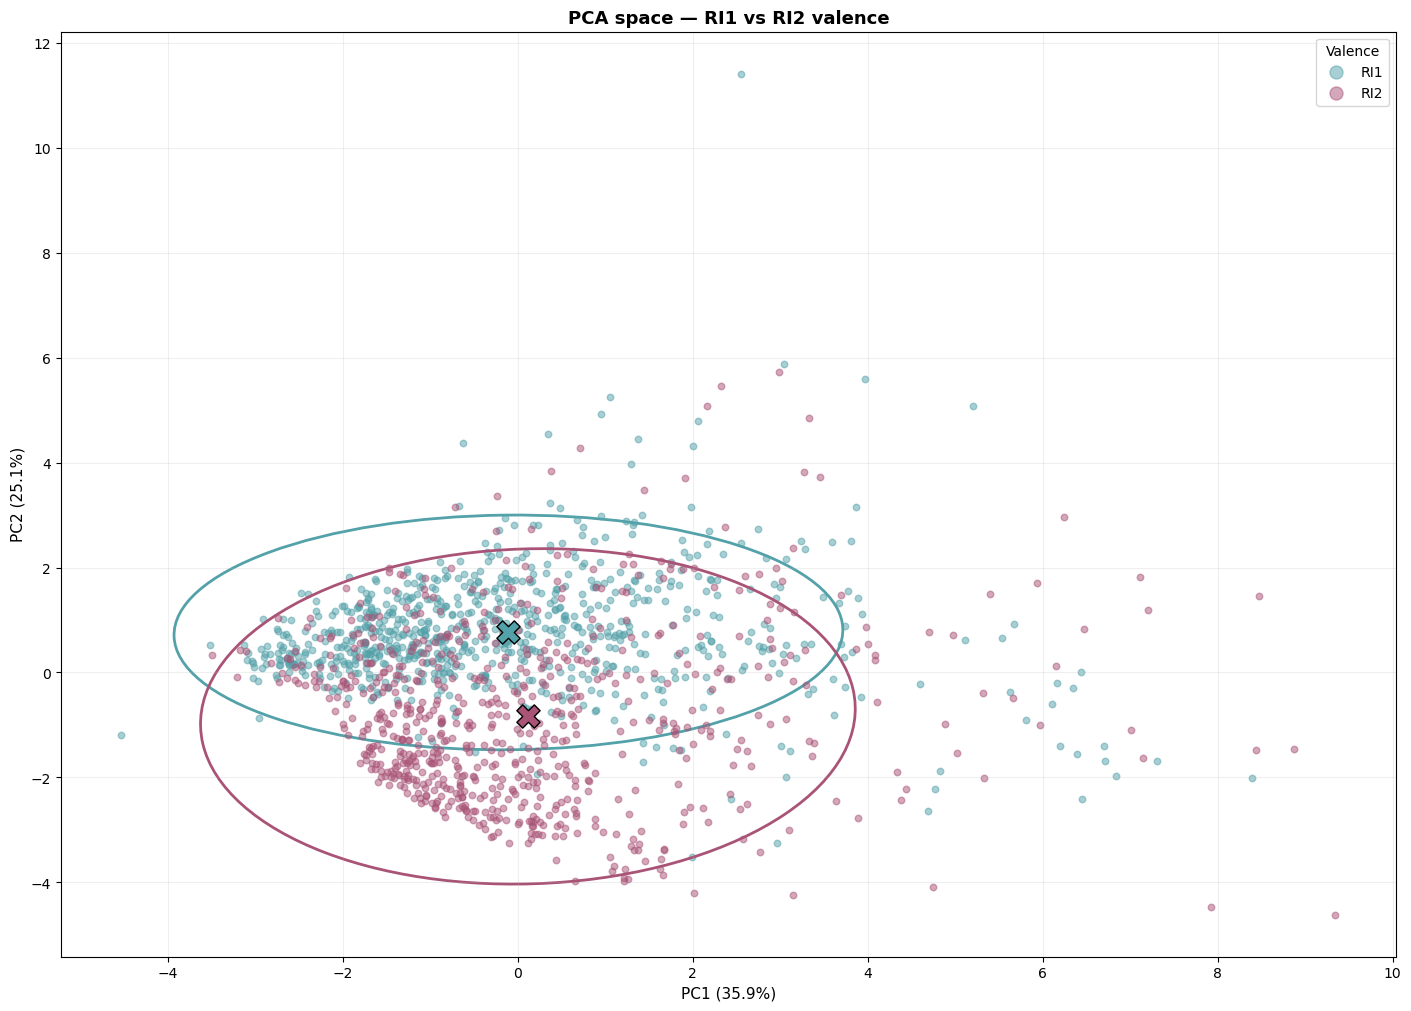

In [30]:
import matplotlib.pyplot as plt
import numpy as np

hc_colors = [
    "#e6194b", "#3cb44b", "#4363d8", "#f58231", "#911eb4",
    "#42d4f4", "#f032e6", "#bfef45", "#a9a9a9", "#469990",
]

# ── Key fix: for each window, assign it to whichever feature has the 
# highest absolute z-score — so each point appears only ONCE, 
# colored by its most dominant feature
dominant_feature_idx = np.argmax(np.abs(X_top_z), axis=1)

print("Windows dominated by each feature:")
for i, feat in enumerate(top_abs_features):
    n = (dominant_feature_idx == i).sum()
    print(f"  [{i}] {feat:40s}  n={n} windows ({n/len(dominant_feature_idx)*100:.1f}%)")

# ── Figure 1: dominant feature per window ────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(14, 10), constrained_layout=True)

feature_handles = []
for i, feat in enumerate(top_abs_features):
    mask = dominant_feature_idx == i
    if mask.sum() == 0:
        continue
    color = hc_colors[i % len(hc_colors)]
    sc = ax1.scatter(
        Z[mask, 0], Z[mask, 1],
        s=22,
        alpha=0.6,
        color=color,
        label=f"{feat} (n={mask.sum()})",
        zorder=2,
    )
    feature_handles.append(sc)

# Overlay valence centroids with marker shape indicating RI1 vs RI2
for lab in labels_sorted:
    mask = (pca_df["valence"] == lab).values
    c = np.array([Z[mask, 0].mean(), Z[mask, 1].mean()])
    ax1.scatter(*c, s=300, marker="X", color=palette[lab],
                edgecolor="white", linewidth=1.5, zorder=5,
                label=f"centroid: {lab}")

ax1.set_title("PCA space — windows colored by dominant feature\n(each point = whichever feature has highest |z-score|)",
              fontsize=12, fontweight="bold")
ax1.set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)", fontsize=11)
ax1.set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)", fontsize=11)
ax1.legend(handles=feature_handles, title="Dominant feature", fontsize=8,
           title_fontsize=9, bbox_to_anchor=(1.01, 1), loc="upper left", markerscale=2)
ax1.grid(alpha=0.2)
plt.savefig("panel_G3a_dominant_feature.svg", bbox_inches="tight", transparent=True)
plt.show()

# ── Figure 2: RI1 vs RI2 valence ─────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(14, 10), constrained_layout=True)

for lab in labels_sorted:
    mask = (pca_df["valence"] == lab).values
    ax2.scatter(
        Z[mask, 0], Z[mask, 1],
        s=22, alpha=0.5,
        color=palette[lab],
        label=lab,
    )
    c = np.array([Z[mask, 0].mean(), Z[mask, 1].mean()])
    ax2.scatter(*c, s=280, marker="X", color=palette[lab],
                edgecolor="black", linewidth=1.0, zorder=5)
    _cov_ellipse(Z[mask], ax2, n_std=2.0, color=palette[lab], linewidth=2.0)

ax2.set_title("PCA space — RI1 vs RI2 valence", fontsize=13, fontweight="bold")
ax2.set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)", fontsize=11)
ax2.set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)", fontsize=11)
ax2.legend(title="Valence", fontsize=10, title_fontsize=10, markerscale=2)
ax2.grid(alpha=0.2)
plt.savefig("panel_G3b_valence.svg", bbox_inches="tight", transparent=True)
plt.show()

Top features used:
breathing_rate_hz                   coef=-0.8347 favors RI1
cv_inhale_dur                       coef=-0.7483 favors RI1
mean_peak_insp_flow                 coef=-0.7329 favors RI1
pct_breaths_with_exhale_pause       coef=-0.6565 favors RI1
cv_exhale_dur                       coef=-0.6299 favors RI1
mean_exhale_dur_sec                 coef= 0.7601 favors RI2
cv_inhale_vol                       coef= 0.4457 favors RI2
exhale_pause_duty_cycle             coef= 0.3725 favors RI2
ventilation_proxy                   coef= 0.3057 favors RI2
ie_ratio                            coef= 0.2500 favors RI2


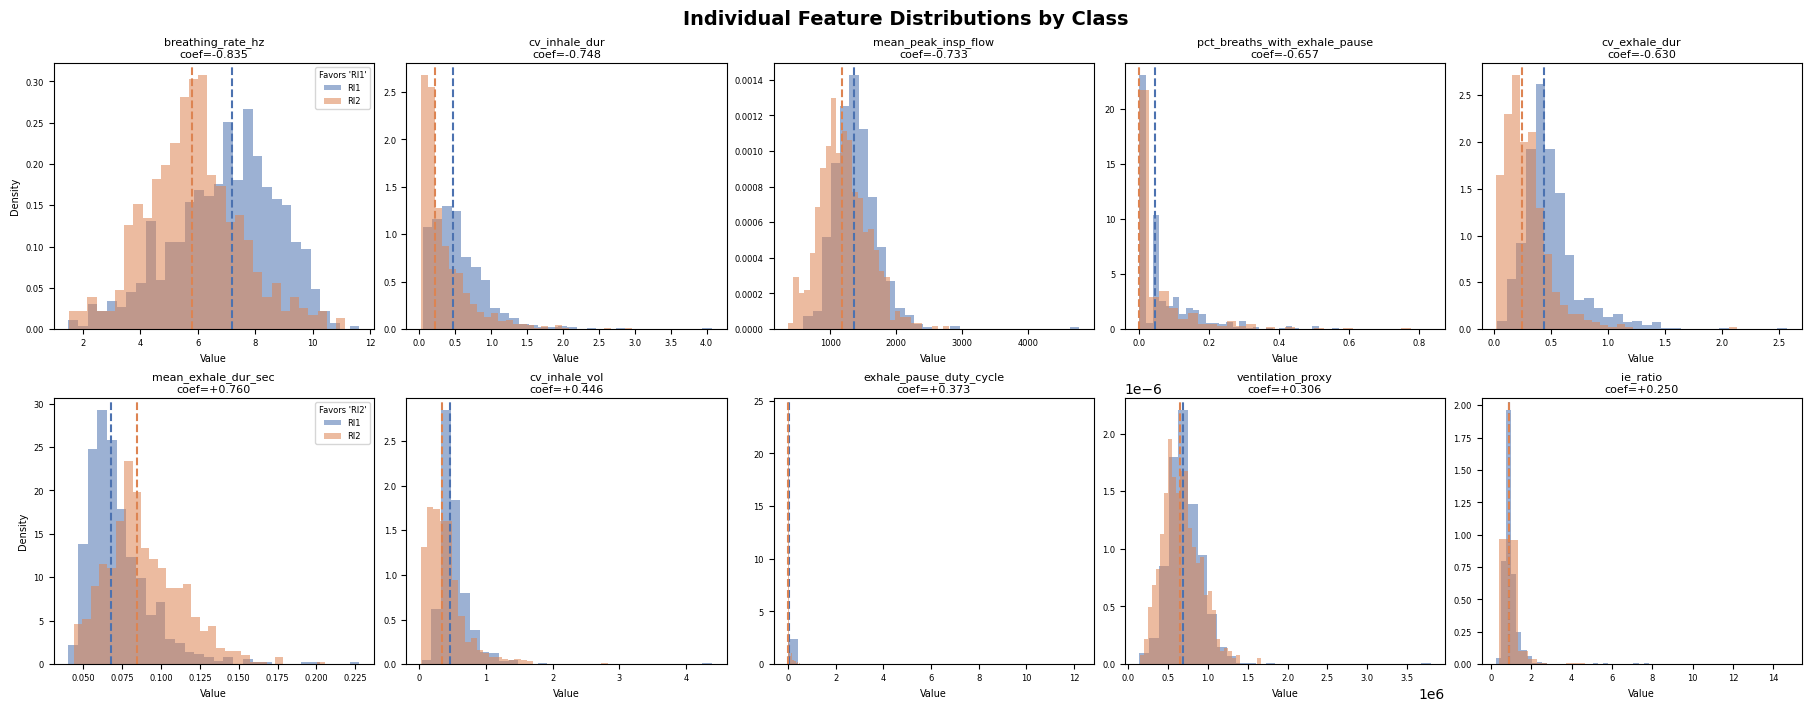

In [26]:
# ==========================================
# TOP 5 FEATURES FROM BOTH CLASSES — INDIVIDUAL FEATURE PLOTS
# ==========================================

from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np

TOP_N = 5

# top negative coefficients = class0 direction
class0_top = coef.sort_values().head(TOP_N)

# top positive coefficients = class1 direction
class1_top = coef.sort_values(ascending=False).head(TOP_N)

top_features = list(dict.fromkeys(
    list(class0_top.index) + list(class1_top.index)
))

print("Top features used:")
for f in top_features:
    direction = class1 if coef[f] > 0 else class0
    print(f"{f:35s} coef={coef[f]: .4f} favors {direction}")

# -----------------------------
# Prepare data
# -----------------------------
X_top = X[top_features].copy()
X_top_imputed = pd.DataFrame(
    SimpleImputer(strategy="median").fit_transform(X_top),
    columns=top_features
)

y_str = pd.Series(y).astype(str).values
classes = sorted(np.unique(y_str))
colors = ["#4C72B0", "#DD8452"]  # blue=class0, orange=class1

# -----------------------------
# Plot: 2 rows × 5 cols — class0 features on top, class1 on bottom
# -----------------------------
class0_features = list(class0_top.index)
class1_features = list(class1_top.index)

fig, axes = plt.subplots(2, TOP_N, figsize=(18, 7), constrained_layout=True)
fig.suptitle("Individual Feature Distributions by Class", fontsize=14, fontweight="bold")

for row, (feature_group, group_label) in enumerate([
    (class0_features, f"Favors '{class0}'"),
    (class1_features, f"Favors '{class1}'"),
]):
    for col, feat in enumerate(feature_group):
        ax = axes[row, col]

        for cls, color in zip(classes, colors):
            vals = X_top_imputed.loc[y_str == cls, feat].dropna()
            ax.hist(vals, bins=30, alpha=0.55, color=color, label=cls, density=True)

            # median line
            med = vals.median()
            ax.axvline(med, color=color, linewidth=1.5, linestyle="--")

        # coefficient annotation
        coef_val = coef[feat]
        ax.set_title(f"{feat}\ncoef={coef_val:+.3f}", fontsize=8, pad=4)
        ax.set_xlabel("Value", fontsize=7)
        ax.set_ylabel("Density" if col == 0 else "", fontsize=7)
        ax.tick_params(labelsize=6)

        if col == 0:
            ax.legend(fontsize=6, title=group_label, title_fontsize=6)

plt.savefig("individual_feature_distributions.svg", bbox_inches="tight", transparent=True)
plt.show()